# Colunas do dataset SINAN Dengue

#### Dados Temporais e Demográficos
- DT_SIN_PRI: Data de Início dos Primeiros Sintomas. É a data base para o cálculo da semana epidemiológica.

- NU_IDADE_N: Idade do paciente. O formato do SINAN é composto: o primeiro dígito indica a unidade (1-Hora, 2-Dia, 3-Mês, 4-Ano) e os três seguintes a quantidade. (Ex: 4025 = 25 anos).

- CS_SEXO: Sexo do paciente (M para Masculino, F para Feminino, I para Ignorado).

- CS_GESTANT: Situação gestacional da paciente. Indica se é gestante (e o trimestre) ou se a pergunta não se aplica.

#### Sinais Clínicos e Sintomas (Semicológicas)
- FEBRE: Presença de febre.

- MIALGIA: Dores musculares.

- CEFALEIA: Dor de cabeça.

- EXANTEMA: Manchas avermelhadas na pele.

- VOMITO: Episódios de vômito.

- NAUSEA: Sensação de enjoo.

- DOR_RETRO: Dor retro-orbital (dor atrás dos olhos).

- ARTRALGIA: Dores nas articulações.

- ARTRITE: Inflamação/inchaço nas articulações.

- CONJUNTVIT: Conjuntivite não purulenta.

- PETEQUIA_N: Presença de petéquias (pontos vermelhos de hemorragia sob a pele).

- LACO: Resultado da "Prova do Laço" (positivo ou negativo)


#### Comorbidades (Doenças Pré-existentes)
- DIABETES: Paciente possui Diabetes Mellitus.

- HIPERTENSA: Paciente possui Hipertensão Arterial.

- RENAL: Paciente possui Doença Renal Crônica.

- HEMATOLOG: Paciente possui Doenças Hematológicas (ex: Anemia Falciforme).

- HEPATOPAT: Paciente possui Doenças do Fígado

##### Observação sobre os valores:
###### Para as colunas de sintomas e comorbidades, os valores padrão são:

1: Sim

2: Não

9: Ignorado/Branco

# Análise Exploratória

In [ ]:
import pandas as pd
import numpy as np
import sys
import os
import gc

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print(f'MatplotLib: {matplotlib.__version__}')
print(f'Seaborn: {sns.__version__}')

Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
MatplotLib: 3.10.0
Seaborn: 0.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [ ]:
def save_data_frame(df: pd.DataFrame, path_dataset: str):
  df.to_csv(path_dataset, index=True)

In [ ]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [ ]:
path_dengue_rj = '/content/drive/MyDrive/ML-UFF/dengue_rj_2020_2026.csv'

In [ ]:
df = get_data_frame(path_dengue_rj)

In [ ]:
df.shape, df.columns

((132407, 24),
 Index(['Unnamed: 0', 'DT_SIN_PRI', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT',
        'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
        'DOR_RETRO', 'ARTRALGIA', 'ARTRITE', 'CONJUNTVIT', 'PETEQUIA_N', 'LACO',
        'DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG', 'HEPATOPAT',
        'CLASSI_FIN', 'EVOLUCAO'],
       dtype='object'))

In [ ]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'])
df.set_index('DT_SIN_PRI', inplace=True)

In [ ]:
df.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-04-21', '2026-04-21', '2026-04-21', '2026-04-21',
               '2026-04-22', '2026-04-22', '2026-04-22', '2026-04-22',
               '2026-04-22', '2026-04-23'],
              dtype='datetime64[ns]', name='DT_SIN_PRI', length=132407, freq=None)

In [ ]:
 # Verificando de há NaNs
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.head()

,NU_IDADE_N,CS_SEXO,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,...,CONJUNTVIT,PETEQUIA_N,LACO,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT,CLASSI_FIN,EVOLUCAO
DT_SIN_PRI,,,,,,,,,,,,,,,,,,,,,
2020-01-01,4062,F,5.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,...,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,5.0,1.0
2020-01-01,4062,F,5.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0,1.0
2020-01-01,4039,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-01-01,4030,F,5.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,...,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,10.0,9.0
2020-01-01,4032,M,6.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,10.0,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 132407 entries, 2020-01-01 to 2026-04-23
Data columns (total 22 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   NU_IDADE_N  132407 non-null  int64  
 1   CS_SEXO     132407 non-null  object 
 2   CS_GESTANT  132407 non-null  float64
 3   FEBRE       132407 non-null  float64
 4   MIALGIA     132407 non-null  float64
 5   CEFALEIA    132407 non-null  float64
 6   EXANTEMA    132407 non-null  float64
 7   VOMITO      132407 non-null  float64
 8   NAUSEA      132407 non-null  float64
 9   DOR_RETRO   132407 non-null  float64
 10  ARTRALGIA   132407 non-null  float64
 11  ARTRITE     132407 non-null  float64
 12  CONJUNTVIT  132407 non-null  float64
 13  PETEQUIA_N  132407 non-null  float64
 14  LACO        132407 non-null  float64
 15  DIABETES    132407 non-null  float64
 16  HIPERTENSA  132407 non-null  float64
 17  RENAL       132407 non-null  float64
 18  HEMATOLOG   132407 non-null 

In [ ]:
df.describe()

,NU_IDADE_N,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,ARTRALGIA,...,CONJUNTVIT,PETEQUIA_N,LACO,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT,CLASSI_FIN,EVOLUCAO
count,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,...,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000,132407.000000
mean,4021.701428,5.615209,1.038850,1.138603,1.161336,1.899847,1.732680,1.605784,1.671974,1.794565,...,1.976534,1.945350,1.971633,1.963642,1.909944,1.994743,1.992855,1.993452,10.000627,1.350261
std,121.248417,0.839112,0.193238,0.345533,0.367842,0.300205,0.442562,0.488684,0.469496,0.404020,...,0.151377,0.227296,0.166020,0.187179,0.286263,0.072311,0.084224,0.080655,0.396339,1.635660
min,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4018.000000,5.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
50%,4028.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
75%,4044.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
max,4405.000000,9.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,12.000000,9.000000


### Removendo Dados Duplicados

In [ ]:
# Duplicados Linhas, Data e Colunas
duplicadas_com_data = df.reset_index().duplicated().sum()

print(f"Linhas com mesma data e mesmos sintomas/dados: {duplicadas_com_data}")

Linhas com mesma data e mesmos sintomas/dados: 11275


In [ ]:
# Filtra o DataFrame mostrando as linhas repetidas (incluindo a data)
df_repetidos = df[df.reset_index().duplicated(keep=False).values]

# Ordena pelo índice (data) para ver os pares/grupos juntos
df_repetidos.sort_index().head(10)

,NU_IDADE_N,CS_SEXO,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,...,CONJUNTVIT,PETEQUIA_N,LACO,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT,CLASSI_FIN,EVOLUCAO
DT_SIN_PRI,,,,,,,,,,,,,,,,,,,,,
2020-01-01,4039,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-01-01,4039,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-01-26,4012,M,6.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-01-26,4012,M,6.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-02-17,4027,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-02-17,4027,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-03-17,4008,F,6.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-03-17,4008,F,6.0,1.0,1.0,1.0,2.0,1.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0
2020-03-29,4027,F,5.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,5.0,1.0


In [ ]:
# Mantém apenas um registro por data/sintoma idêntico
df = df.reset_index().drop_duplicates().set_index('DT_SIN_PRI')

In [ ]:
df.shape, df.columns

((121132, 22),
 Index(['NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'FEBRE', 'MIALGIA', 'CEFALEIA',
        'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_RETRO', 'ARTRALGIA', 'ARTRITE',
        'CONJUNTVIT', 'PETEQUIA_N', 'LACO', 'DIABETES', 'HIPERTENSA', 'RENAL',
        'HEMATOLOG', 'HEPATOPAT', 'CLASSI_FIN', 'EVOLUCAO'],
       dtype='object'))

In [ ]:
df.describe()

,NU_IDADE_N,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,ARTRALGIA,...,CONJUNTVIT,PETEQUIA_N,LACO,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT,CLASSI_FIN,EVOLUCAO
count,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,...,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000,121132.000000
mean,4021.237014,5.621925,1.042317,1.149094,1.174050,1.891135,1.719075,1.588986,1.660544,1.781858,...,1.974383,1.940420,1.969059,1.960390,1.902619,1.994254,1.992190,1.992843,10.000768,1.379891
std,126.520150,0.860527,0.201313,0.356182,0.379154,0.311471,0.449453,0.492020,0.473527,0.412986,...,0.157989,0.236707,0.173160,0.195041,0.296478,0.075583,0.088027,0.084299,0.413457,1.700124
min,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,4018.000000,5.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
50%,4029.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
75%,4044.000000,6.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,10.000000,1.000000
max,4405.000000,9.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,12.000000,9.000000


In [ ]:
 # Verificando de há NaNs
df.isna().sum().sum()

np.int64(0)

### Tratamento

In [ ]:
df = df.drop(df[df['CS_SEXO'] == 'I'].index)

In [ ]:
# Convertendo idade
def converter_idade_sinan(idade_codificada):
    if pd.isna(idade_codificada): # pd.isna lida com None e np.nan
        return 0

    s = str(int(idade_codificada)).zfill(4)
    unidade = s[0]
    valor = int(s[1:])

    opcoes = {
        '4': valor,
        '3': valor / 12,
        '2': valor / 365,
        '1': 0
    }

    # Se não achar (tipo 9), retorna 0 em vez de None
    return opcoes.get(unidade, 0)

In [ ]:
df['NU_IDADE_N'] = pd.to_numeric(df['NU_IDADE_N'], errors='coerce')

In [ ]:
# Aplicando a conversão
df['IDADE'] = df['NU_IDADE_N'].apply(converter_idade_sinan)

In [ ]:
# Agrupamento por Faixa Etária
df['FAIXA_ETARIA'] = pd.cut(
    df['IDADE'],
    bins=[0, 12, 18, 60, 120],
    labels=['Criança', 'Adolescente', 'Adulto', 'Idoso'],
    include_lowest=True
)

# Caso ainda existam NaNs (por conta de idades ignoradas/código 9),
# categoriza como 'Não Informado'
df['FAIXA_ETARIA'] = df['FAIXA_ETARIA'].astype(object).fillna('Não Informado')

In [ ]:
df.drop(columns=['NU_IDADE_N'],inplace=True)

In [ ]:
# Considerando todos os dados de idade acima de 120 como inválidos
df[df['IDADE'] >= 120]

,CS_SEXO,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,ARTRALGIA,...,LACO,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT,CLASSI_FIN,EVOLUCAO,IDADE,FAIXA_ETARIA
DT_SIN_PRI,,,,,,,,,,,,,,,,,,,,,
2021-01-12,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2.0,2.0,2.0,2.0,2.0,2.0,10.0,1.0,402.0,Não Informado
2023-11-26,F,5.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,11.0,9.0,401.0,Não Informado
2025-08-13,F,5.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2.0,1.0,1.0,2.0,2.0,2.0,10.0,1.0,405.0,Não Informado


In [ ]:
# Remove as linhas onde idade é maior ou igual a 120 anos
df = df.drop(df[df['IDADE'] >= 120].index)

In [ ]:
df.shape

(92794, 23)

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df['YEAR'] = df.index.year
df['MONTH'] = df.index.month
df['DAY_WEEK'] = df.index.day_of_week
df['DAY_MONTH'] = df.index.day
df['DAY_MONTH_START'] = df.index.is_month_start.astype(int)
df['DAY_MONTH_END'] = df.index.is_month_end.astype(int)
df['DAY_QUARTER_START'] = df.index.is_quarter_start.astype(int)
df['DAY_QUARTER_END'] = df.index.is_quarter_end.astype(int)
df['DAY_YEAR_START'] = df.index.is_year_start.astype(int)
df['DAY_YEAR_END'] = df.index.is_year_end.astype(int)
df[['YEAR','MONTH','DAY_WEEK','DAY_MONTH','DAY_MONTH_START','DAY_MONTH_END','DAY_QUARTER_START','DAY_QUARTER_END','DAY_YEAR_START','DAY_YEAR_END','DAY_YEAR_END']]

,YEAR,MONTH,DAY_WEEK,DAY_MONTH,DAY_MONTH_START,DAY_MONTH_END,DAY_QUARTER_START,DAY_QUARTER_END,DAY_YEAR_START,DAY_YEAR_END,DAY_YEAR_END
DT_SIN_PRI,,,,,,,,,,,
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
2020-01-01,2020,1,2,1,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,2026,4,2,22,0,0,0,0,0,0,0
2026-04-22,2026,4,2,22,0,0,0,0,0,0,0
2026-04-22,2026,4,2,22,0,0,0,0,0,0,0


### Análise Demográfica

In [ ]:
df.columns

Index(['CS_SEXO', 'CS_GESTANT', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA',
       'VOMITO', 'NAUSEA', 'DOR_RETRO', 'ARTRALGIA', 'ARTRITE', 'CONJUNTVIT',
       'PETEQUIA_N', 'LACO', 'DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG',
       'HEPATOPAT', 'CLASSI_FIN', 'EVOLUCAO', 'IDADE', 'FAIXA_ETARIA', 'YEAR',
       'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START', 'DAY_MONTH_END',
       'DAY_QUARTER_START', 'DAY_QUARTER_END', 'DAY_YEAR_START',
       'DAY_YEAR_END'],
      dtype='object')

#### Perfil por Sexo (CS_SEXO)

In [ ]:
# Contagem e Percentual
sexo_counts = df['CS_SEXO'].value_counts()
sexo_perc = df['CS_SEXO'].value_counts(normalize=True) * 100

print("Distribuição por Sexo:")
print(sexo_perc)

Distribuição por Sexo:
CS_SEXO
F    55.096235
M    44.903765
Name: proportion, dtype: float64


/tmp/ipykernel_1329/2584375941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CS_SEXO', palette='viridis')


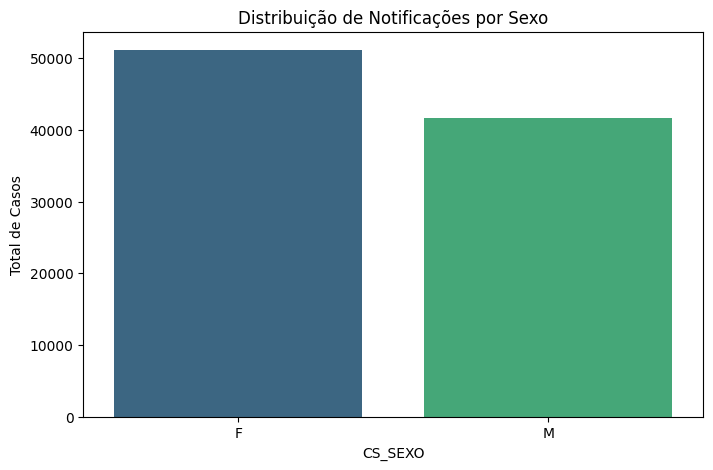

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='CS_SEXO', palette='viridis')
plt.title('Distribuição de Notificações por Sexo')
plt.ylabel('Total de Casos')
plt.show()

In [ ]:
# Agrupamento para ver as porcentagens por ano e
distribuicao = df.groupby(['YEAR', 'CS_SEXO']).size().unstack(fill_value=0)
print("Distribuição Absoluta por Ano e Sexo:")
print(distribuicao)

Distribuição Absoluta por Ano e Sexo:
CS_SEXO      F      M
YEAR                 
2020       615    547
2021       638    510
2022      2244   1756
2023     10596   9793
2024     31786  24708
2025      4563   3806
2026       684    548


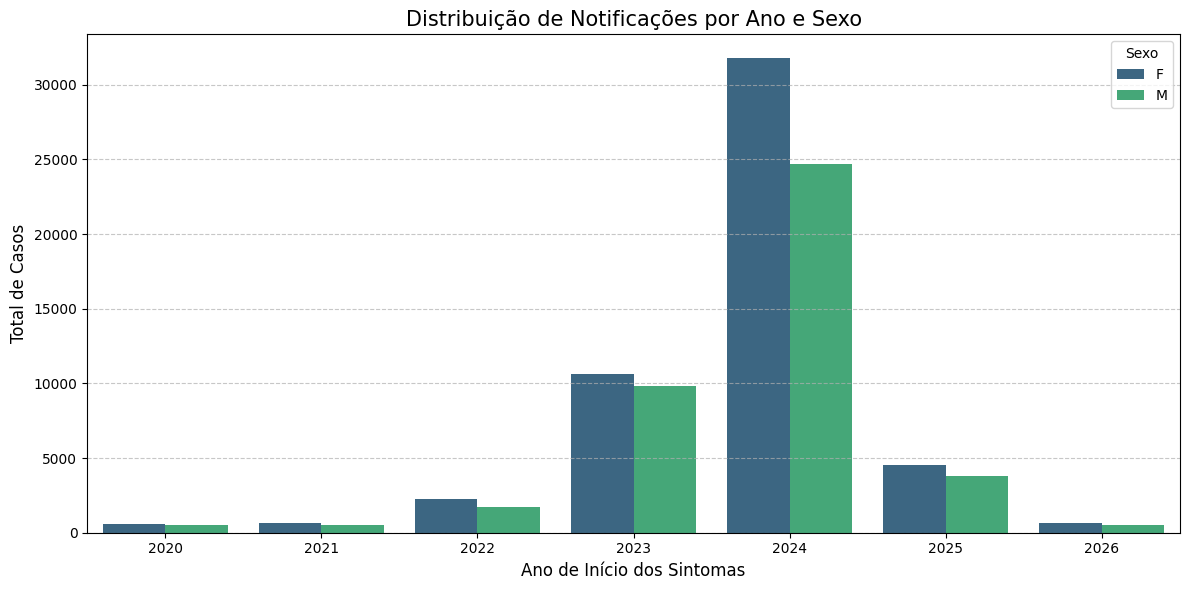

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='YEAR', hue='CS_SEXO', palette='viridis')

plt.title('Distribuição de Notificações por Ano e Sexo', fontsize=15)
plt.xlabel('Ano de Início dos Sintomas', fontsize=12)
plt.ylabel('Total de Casos', fontsize=12)
plt.legend(title='Sexo', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Com faixa etaria
# Agrupamento para ver as porcentagens por ano e
distribuicao = df.groupby(['YEAR', 'CS_SEXO', 'FAIXA_ETARIA']).size().unstack(fill_value=0)
print("Distribuição Absoluta por Ano e Sexo:")
print(distribuicao)

Distribuição Absoluta por Ano e Sexo:
FAIXA_ETARIA  Adolescente  Adulto  Criança  Idoso
YEAR CS_SEXO                                     
2020 F                 52     464       58     41
     M                 41     417       71     18
2021 F                 47     482       79     30
     M                 66     326       94     24
2022 F                194    1587      316    147
     M                227    1079      355     95
2023 F               1355    6787     1804    650
     M               1865    5253     2237    438
2024 F               2985   21856     3836   3109
     M               3012   15726     4199   1771
2025 F                414    3242      603    304
     M                400    2528      688    190
2026 F                 52     513       75     44
     M                 44     399       81     24


#### Perfil por Idade (NU_IDADE_N)

In [ ]:
list(df['FAIXA_ETARIA'].unique())

['Idoso', 'Adulto', 'Criança', 'Adolescente']

In [ ]:
# Estatísticas descritivas
print(f"Média de idade: {df['IDADE'].mean():.2f} anos")
print(f"Mediana de idade: {df['IDADE'].median()} anos")

Média de idade: 31.23 anos
Mediana de idade: 28.0 anos


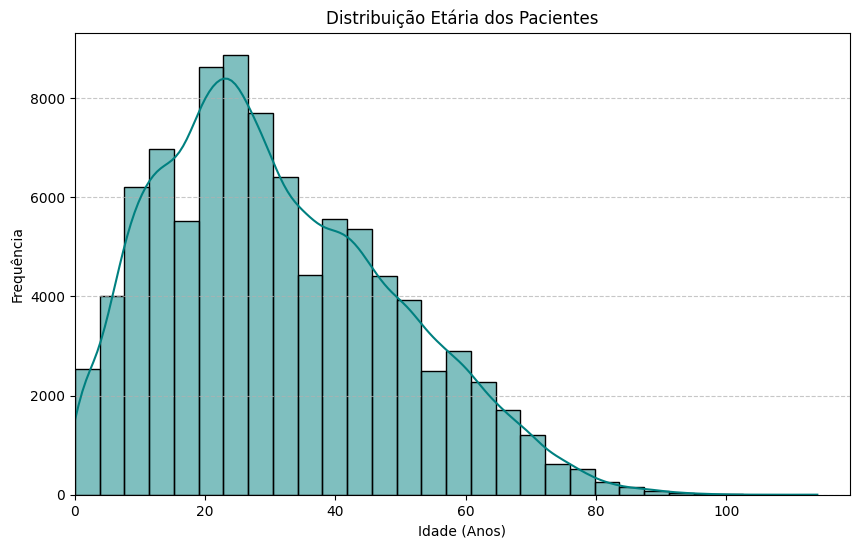

In [ ]:
# Histograma de Idade
plt.figure(figsize=(10, 6))
sns.histplot(df['IDADE'], bins=30, kde=True, color='teal')
plt.title('Distribuição Etária dos Pacientes')
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')

# Ajusta o limite do eixo X para o máximo biológico (evita espaços vazios)
plt.xlim(0, df['IDADE'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1329/3897743036.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))


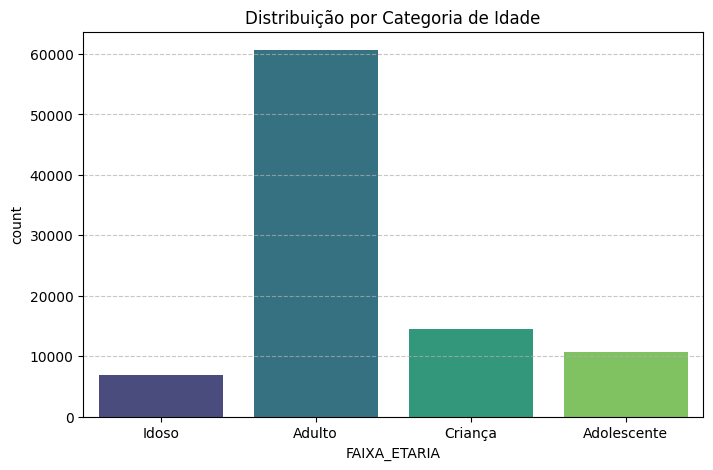

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))
plt.title('Distribuição por Categoria de Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
sexo_name = 'Mulheres'
sexo = df[df['CS_SEXO'] == 'F']
print(f'{sexo_name} - quantidade: {len(sexo)}')

Mulheres - quantidade: 51126


In [ ]:
# Estatísticas descritivas
print(f"{sexo_name}: Média de idade: {sexo['IDADE'].mean():.2f} anos")
print(f"{sexo_name}: Mediana de idade: {sexo['IDADE'].median()} anos")

Mulheres: Média de idade: 32.98 anos
Mulheres: Mediana de idade: 30.0 anos


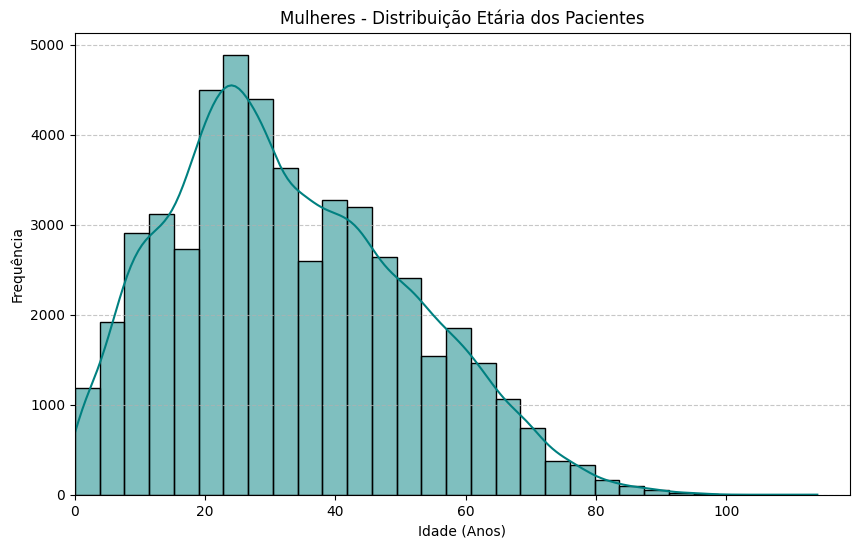

In [ ]:
# Histograma de Idade
plt.figure(figsize=(10, 6))
sns.histplot(sexo['IDADE'], bins=30, kde=True, color='teal')
plt.title(f'{sexo_name} - Distribuição Etária dos Pacientes')
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')

# Ajusta o limite do eixo X para o máximo biológico (evita espaços vazios)
plt.xlim(0, sexo['IDADE'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1329/3850197276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sexo, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))


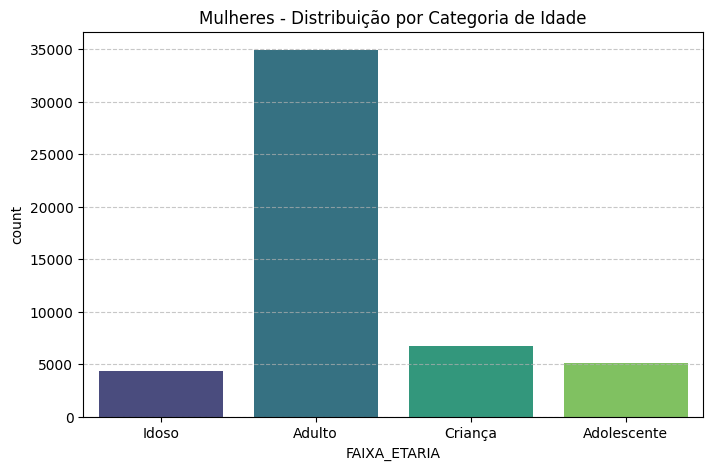

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sexo, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))
plt.title(f'{sexo_name} - Distribuição por Categoria de Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
sexo_name = 'Homens'
sexo = df[df['CS_SEXO'] == 'M']
print(f'{sexo_name} - quantidade: {len(sexo)}')

Homens - quantidade: 41668


In [ ]:
# Estatísticas descritivas
print(f"{sexo_name}: Média de idade: {sexo['IDADE'].mean():.2f} anos")
print(f"{sexo_name}: Mediana de idade: {sexo['IDADE'].median()} anos")

Homens: Média de idade: 29.08 anos
Homens: Mediana de idade: 26.0 anos


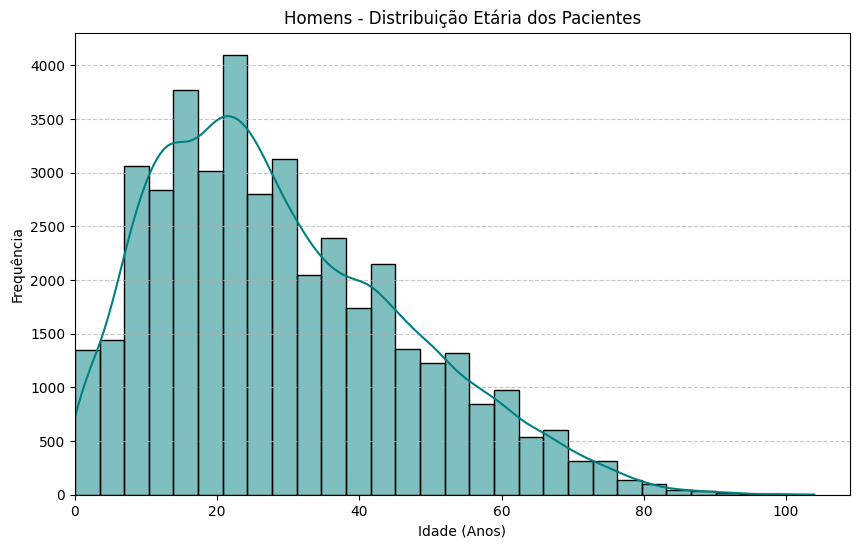

In [ ]:
# Histograma de Idade
plt.figure(figsize=(10, 6))
sns.histplot(sexo['IDADE'], bins=30, kde=True, color='teal')
plt.title(f'{sexo_name} - Distribuição Etária dos Pacientes')
plt.xlabel('Idade (Anos)')
plt.ylabel('Frequência')

# Ajusta o limite do eixo X para o máximo biológico (evita espaços vazios)
plt.xlim(0, sexo['IDADE'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1329/3850197276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sexo, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))


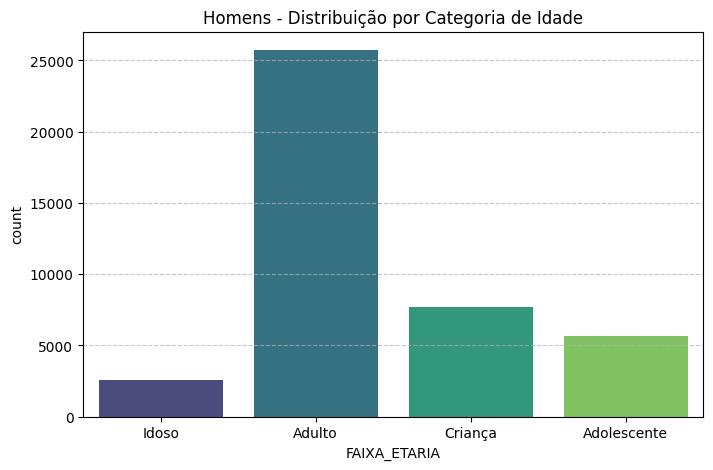

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=sexo, x='FAIXA_ETARIA', palette='viridis', order=list(df['FAIXA_ETARIA'].unique()))
plt.title(f'{sexo_name} - Distribuição por Categoria de Idade')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Perfil dos Sintomas (Análise de Sintomatologia)

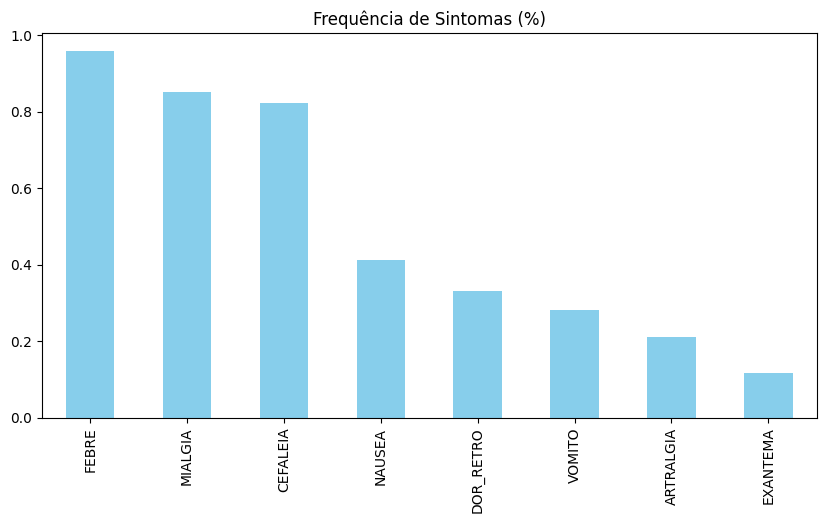

In [ ]:
sintomas = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_RETRO', 'ARTRALGIA']
frequencia = (df[sintomas] == 1).mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
frequencia.plot(kind='bar', color='skyblue')
plt.title('Frequência de Sintomas (%)')
plt.show()

<Axes: title={'center': 'Casos por Semana Epidemiológica'}, xlabel='DT_SIN_PRI'>

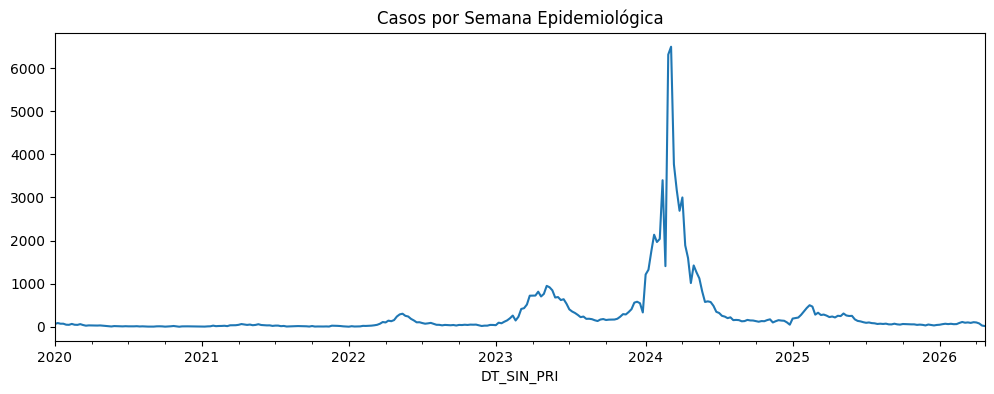

In [ ]:
# Evolução dos casos no tempo (Semanal)
df.resample('W').size().plot(figsize=(12,4), title='Casos por Semana Epidemiológica')

In [ ]:
sexo_name = 'Homens'
sexo = df[df['CS_SEXO'] == 'M']

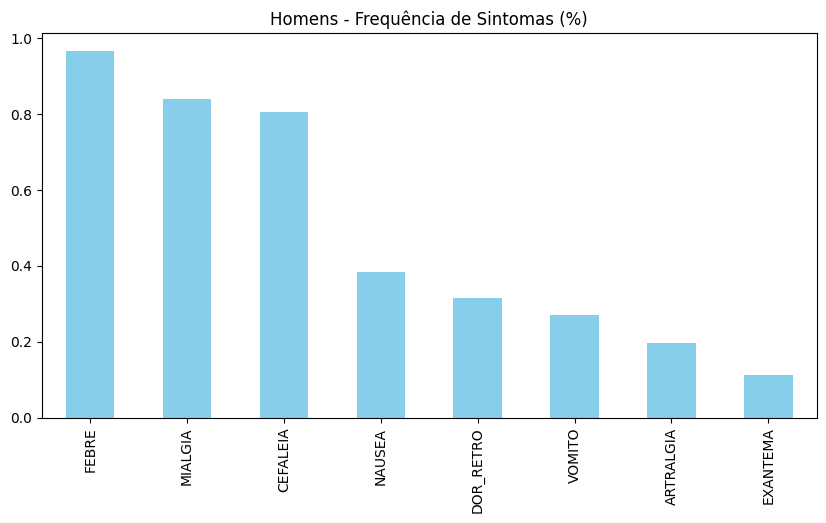

In [ ]:
frequencia = (sexo[sintomas] == 1).mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
frequencia.plot(kind='bar', color='skyblue')
plt.title(f'{sexo_name} - Frequência de Sintomas (%)')
plt.show()

<Axes: title={'center': 'Homens - Casos por Semana Epidemiológica'}, xlabel='DT_SIN_PRI'>

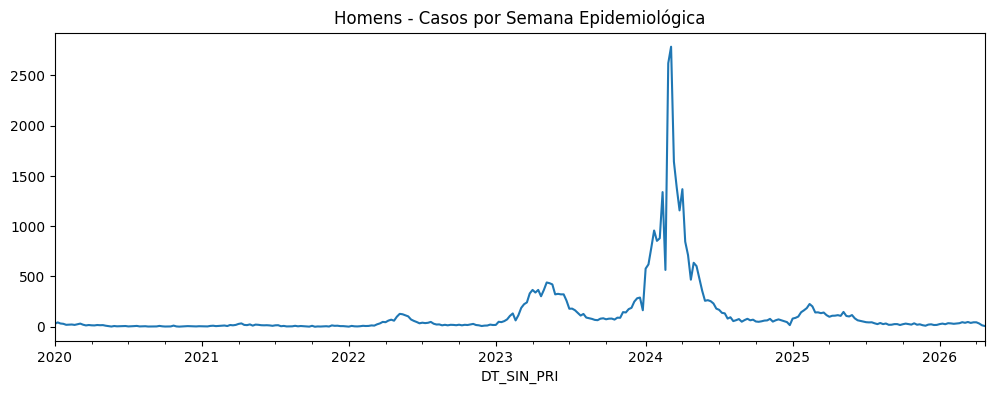

In [ ]:
# Evolução dos casos no tempo (Semanal)
sexo.resample('W').size().plot(figsize=(12,4), title=f'{sexo_name} - Casos por Semana Epidemiológica')

In [ ]:
sexo_name = 'Mulheres'
sexo = df[df['CS_SEXO'] == 'F']

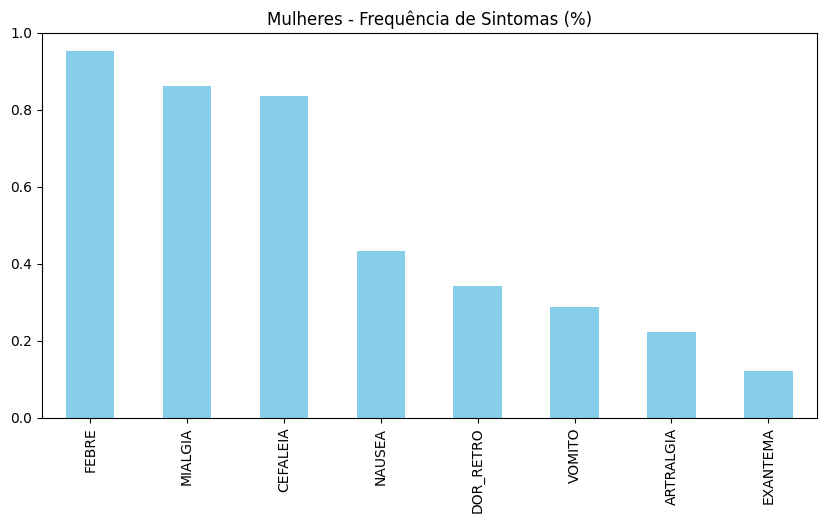

In [ ]:
frequencia = (sexo[sintomas] == 1).mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
frequencia.plot(kind='bar', color='skyblue')
plt.title(f'{sexo_name} - Frequência de Sintomas (%)')
plt.show()

<Axes: title={'center': 'Mulheres - Casos por Semana Epidemiológica'}, xlabel='DT_SIN_PRI'>

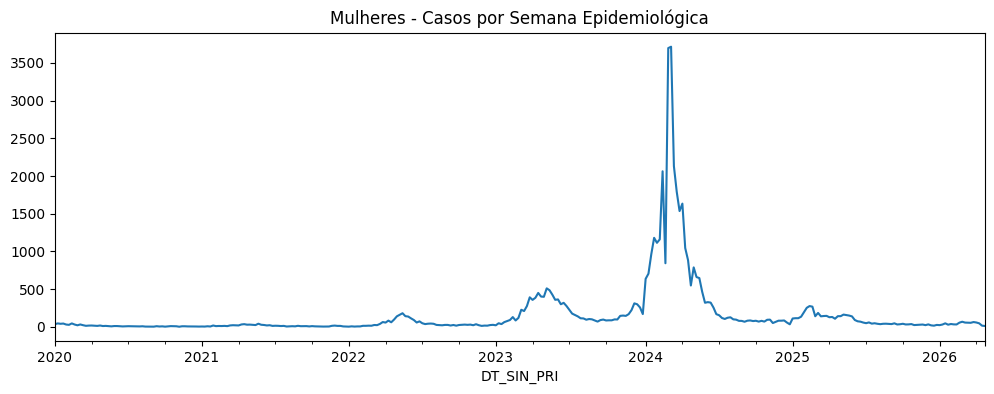

In [ ]:
# Evolução dos casos no tempo (Semanal)
sexo.resample('W').size().plot(figsize=(12,4), title=f'{sexo_name} - Casos por Semana Epidemiológica')

### Análise de Gestantes (CS_GESTANT)

In [ ]:
gestacao_labels = {1: '1º Trim', 2: '2º Trim', 3: '3º Trim', 4: 'Idade Gest. Ignorada', 5: 'Não', 6: 'Não se aplica', 9: 'Ignorado'}

In [ ]:
# Não temos homens gestantes
h = df[(df['CS_SEXO'] == 'M')]
h['CS_GESTANT'].unique()

array([6., 9., 5.])

In [ ]:
# Filtrando apenas mulheres para análise de gestação
mulheres = df[df['CS_SEXO'] == 'F']

In [ ]:
gestantes = mulheres[mulheres['CS_GESTANT'].isin([1, 2, 3, 4])].copy()

# Mapeamos os labels para facilitar a visualização
gestacao_labels = {
    1: '1º Trimestre',
    2: '2º Trimestre',
    3: '3º Trimestre',
    4: 'Idade Gest. Ignorada'
}

gestantes['CS_GESTANT_DESC'] = gestantes['CS_GESTANT'].map(gestacao_labels)

print(f'Quantidade de gestantes {len(gestantes)}')
print(gestantes['CS_GESTANT_DESC'].value_counts())

Quantidade de gestantes 995
CS_GESTANT_DESC
2º Trimestre            330
3º Trimestre            256
1º Trimestre            245
Idade Gest. Ignorada    164
Name: count, dtype: int64


In [ ]:
gestantes

,CS_SEXO,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,ARTRALGIA,...,MONTH,DAY_WEEK,DAY_MONTH,DAY_MONTH_START,DAY_MONTH_END,DAY_QUARTER_START,DAY_QUARTER_END,DAY_YEAR_START,DAY_YEAR_END,CS_GESTANT_DESC
DT_SIN_PRI,,,,,,,,,,,,,,,,,,,,,
2020-01-01,F,3.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,...,1,2,1,1,0,1,0,1,0,3º Trimestre
2020-01-09,F,2.0,1.0,2.0,1.0,2.0,2.0,1.0,1.0,2.0,...,1,3,9,0,0,0,0,0,0,2º Trimestre
2020-01-15,F,3.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,...,1,2,15,0,0,0,0,0,0,3º Trimestre
2020-01-20,F,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1,0,20,0,0,0,0,0,0,1º Trimestre
2020-01-21,F,3.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,...,1,1,21,0,0,0,0,0,0,3º Trimestre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-07,F,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2,5,7,0,0,0,0,0,0,1º Trimestre
2026-02-11,F,3.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,...,2,2,11,0,0,0,0,0,0,3º Trimestre
2026-03-27,F,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,...,3,4,27,0,0,0,0,0,0,2º Trimestre


/tmp/ipykernel_1329/1893355844.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


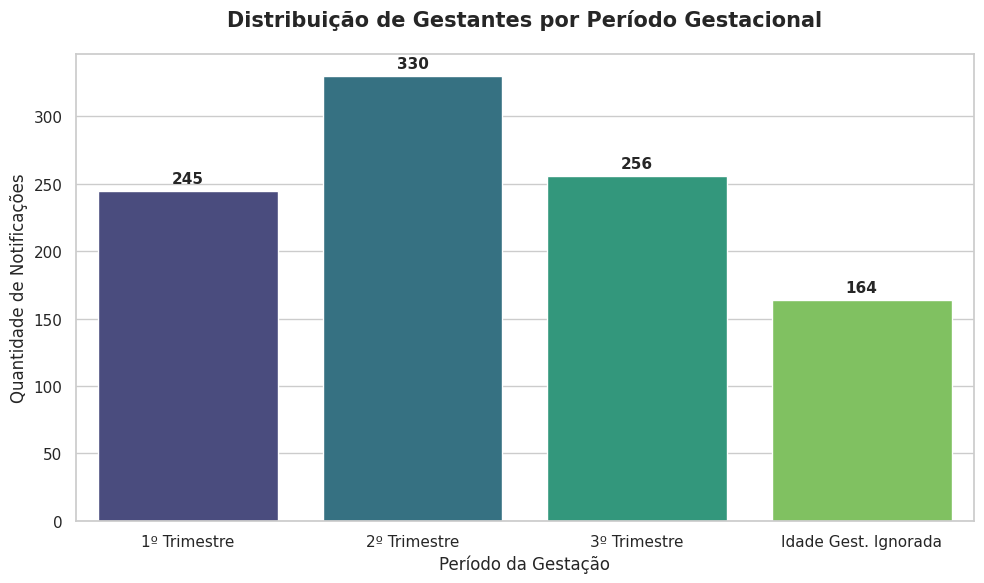

In [ ]:
# Configuração do estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Ordem lógica para os trimestres no eixo X
ordem = ['1º Trimestre', '2º Trimestre', '3º Trimestre', 'Idade Gest. Ignorada']

# Geração do gráfico de barras
ax = sns.countplot(
    data=gestantes,
    x='CS_GESTANT_DESC',
    order=ordem,
    palette='viridis'
)

# Títulos e rótulos
plt.title('Distribuição de Gestantes por Período Gestacional', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Período da Gestação', fontsize=12)
plt.ylabel('Quantidade de Notificações', fontsize=12)

# Adicionando os valores sobre as barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
dates = pd.date_range(start=gestantes.index.min(), end=gestantes.index.max())
mock_data = {
    'CS_GESTANT_DESC': np.random.choice(['1º Trimestre', '2º Trimestre', '3º Trimestre', 'Idade Gest. Ignorada'], len(dates))
}
gestantes = pd.DataFrame(mock_data, index=dates)
mock_data = {
    'CS_GESTANT_DESC': np.random.choice(['1º Trimestre', '2º Trimestre', '3º Trimestre', 'Idade Gest. Ignorada'], len(dates))
}
gestantes = pd.DataFrame(mock_data, index=gestantes.index)

In [ ]:
# Agrupando por ano e pela descrição da gestação
contagem_anual = gestantes.groupby([gestantes.index.year, 'CS_GESTANT_DESC']).size().unstack(fill_value=0)

<Figure size 1200x700 with 0 Axes>

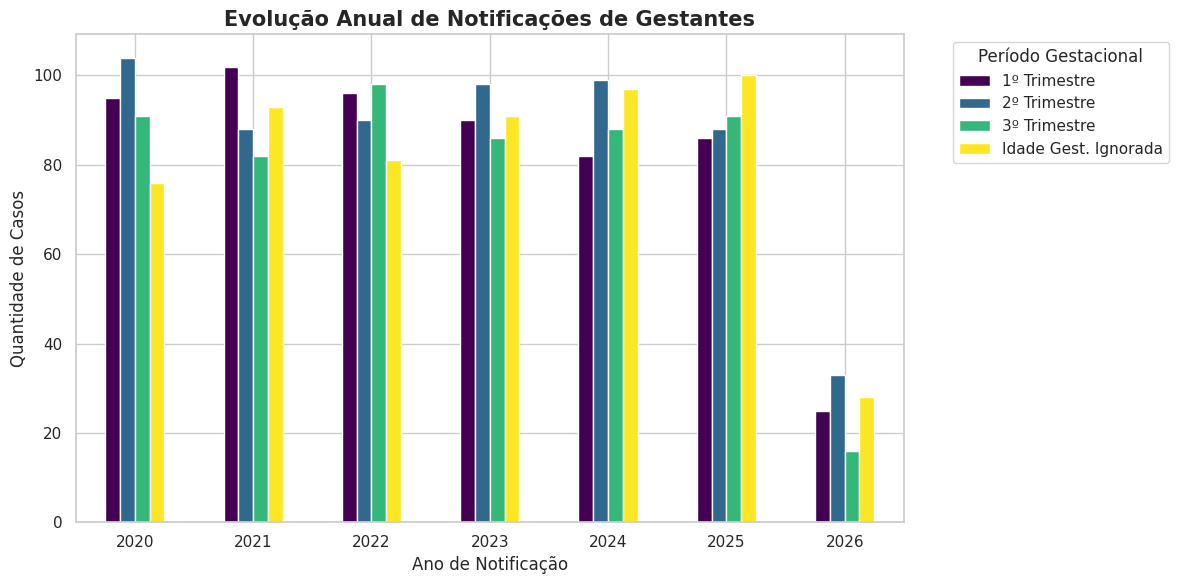

In [ ]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

contagem_anual.plot(kind='bar', stacked=False, figsize=(12, 6), colormap='viridis')

plt.title('Evolução Anual de Notificações de Gestantes', fontsize=15, fontweight='bold')
plt.xlabel('Ano de Notificação', fontsize=12)
plt.ylabel('Quantidade de Casos', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Período Gestacional', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Exibindo a tabela resultante
print("Contagem por Ano:")
d = pd.DataFrame(contagem_anual)
d

Contagem por Ano:


CS_GESTANT_DESC,1º Trimestre,2º Trimestre,3º Trimestre,Idade Gest. Ignorada
2020,95,104,91,76
2021,102,88,82,93
2022,96,90,98,81
2023,90,98,86,91
2024,82,99,88,97
2025,86,88,91,100
2026,25,33,16,28


### Análise de Gravidade e Desfecho

In [ ]:
# Mapeamento oficial do SINAN
# CLASSI_FIN: 1-Dengue / 5-Descartado / 8-Inconclusivo / 10-Dengue / 11-Dengue com sinais de alarme / 12-Dengue grave
map_classi = {
    1: 'Dengue (Clássica)',
    10: 'Dengue',
    11: 'Dengue c/ sinais de alarme',
    12: 'Dengue Grave',
    5: 'Descartado',
    8: 'Inconclusivo'
}

In [ ]:
# Aplicando mapeamento
df['CLASSIFICACAO'] = df['CLASSI_FIN'].map(map_classi).fillna('Outros/Não Informado')
df['CLASSIFICACAO'].isna().sum().sum(), df['CLASSIFICACAO'].shape

(np.int64(0), (92794,))

In [ ]:
# Agrupamento para ver as porcentagens por ano e
distribuicao = df.groupby(['YEAR', 'CS_SEXO', 'CLASSIFICACAO']).size().unstack(fill_value=0)
print("Distribuição Absoluta por Ano e Sexo:")
d = pd.DataFrame(distribuicao)
d

Distribuição Absoluta por Ano e Sexo:


CLASSIFICACAO  Dengue  Dengue Grave  Dengue c/ sinais de alarme  Descartado  \
YEAR CS_SEXO                                                                  
2020 F            447             1                           0         163   
     M            429             1                           0         115   
2021 F            487             0                           0         148   
     M            387             1                           3         115   
2022 F           2174             3                          36           0   
     M           1676             4                          50           0   
2023 F          10182            12                         371           0   
     M           9413            17                         350           0   
2024 F          30847            26                         895           0   
     M          23900            27                         768           0   
2025 F           4367             8                         124           0   
     M           3645            10                         116           0   
2026 F            670             0                          11           0   
     M            536             0                          12           0   

CLASSIFICACAO  Inconclusivo  Outros/Não Informado  
YEAR CS_SEXO                                       
2020 F                    4                     0  
     M                    2                     0  
2021 F                    3                     0  
     M                    4                     0  
2022 F                   31                     0  
     M                   24                     2  
2023 F                   22                     9  
     M                    9                     4  
2024 F                   18                     0  
     M                   13                     0  
2025 F                   61                     3  
     M                   31                     4  
2026 F                    1                     2  
     M                    0                     0

In [ ]:
df['CLASSIFICACAO'].value_counts()

,count
CLASSIFICACAO,
Dengue,89160
Dengue c/ sinais de alarme,2736
Descartado,541
Inconclusivo,223
Dengue Grave,110
Outros/Não Informado,24


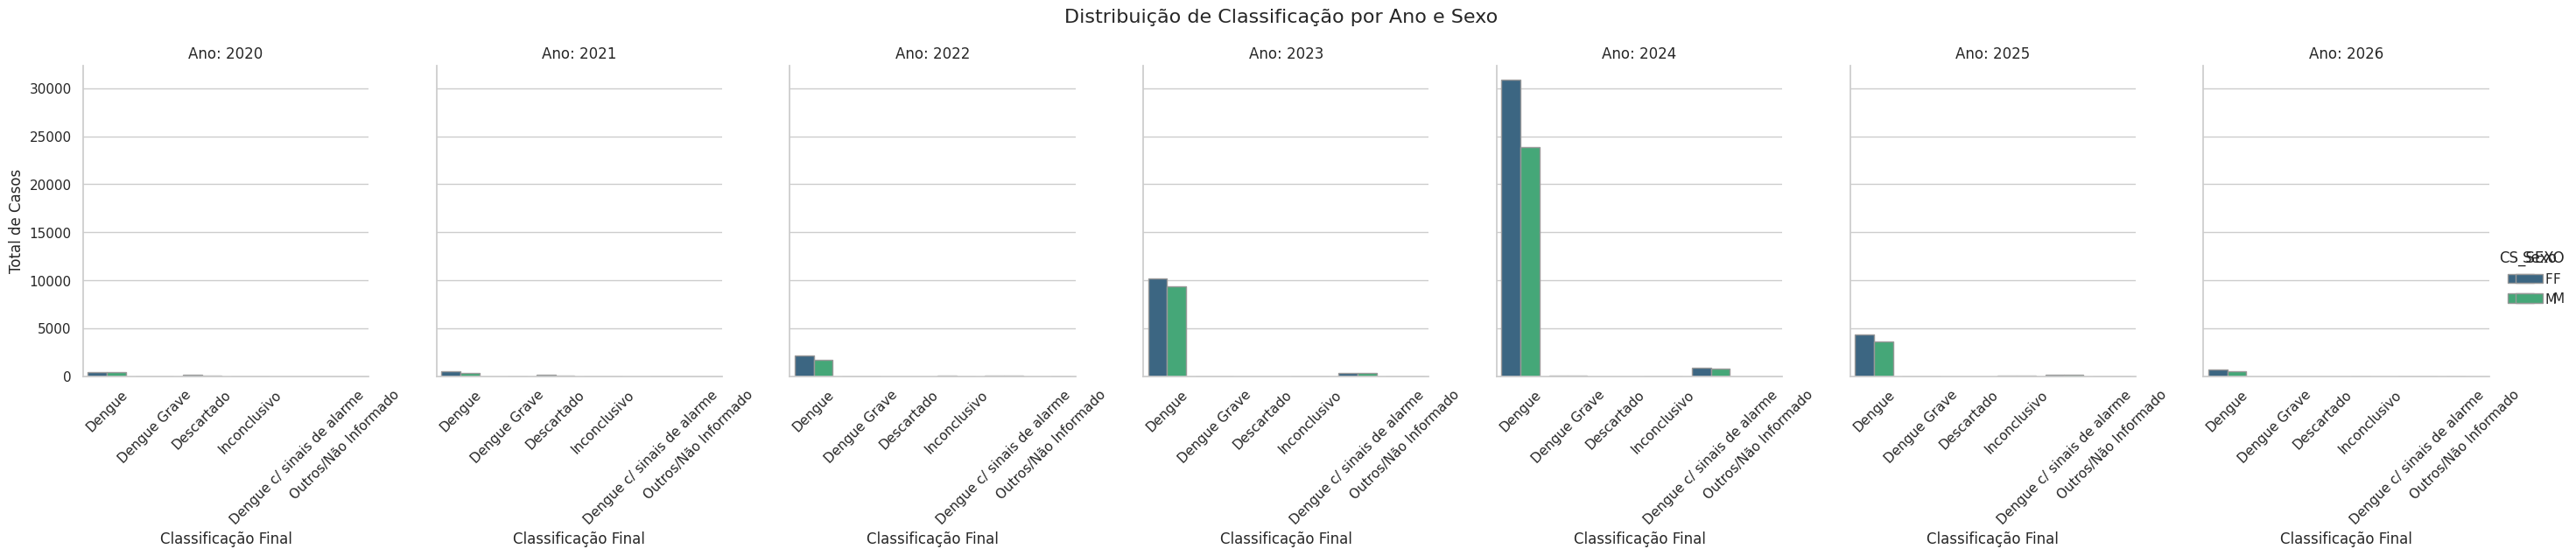

In [ ]:
df_grouped = df.groupby(['YEAR', 'CS_SEXO', 'CLASSIFICACAO']).size().reset_index(name='TOTAL')

# 2. Criando o gráfico facetado por Ano
g = sns.catplot(
    data=df_grouped,
    x='CLASSIFICACAO',
    y='TOTAL',
    hue='CS_SEXO',
    col='YEAR',
    kind='bar',
    palette='viridis',
    height=5,
    aspect=0.8,
    edgecolor='.6'
)

# 3. Ajustes de layout e títulos
g.set_axis_labels("Classificação Final", "Total de Casos")
g.set_titles("Ano: {col_name}")
g.add_legend(title="Sexo")

# Rotacionar os nomes das categorias se forem longos (como "Confirmado Laboratorial")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribuição de Classificação por Ano e Sexo', fontsize=16)

plt.show()

In [ ]:
# EVOLUCAO: 1-Cura / 2-Óbito pelo agravo / 3-Óbito por outras causas / 4-Óbito em investigação / 9-Ignorado
map_evolucao = {
    1: 'Cura',
    2: 'Óbito (Dengue)',
    3: 'Óbito (Outras causas)',
    4: 'Óbito em investigação',
    9: 'Ignorado'
}

In [ ]:
df['DESFECHO'] = df['EVOLUCAO'].map(map_classi).fillna('Outros/Não Informado')
df['DESFECHO'].isna().sum().sum(), df['DESFECHO'].shape

(np.int64(0), (92794,))

In [ ]:
distribuicao = df.groupby(['YEAR', 'CS_SEXO', 'DESFECHO']).size().unstack(fill_value=0)
d = pd.DataFrame(distribuicao)
d

DESFECHO      Dengue (Clássica)  Outros/Não Informado
YEAR CS_SEXO                                         
2020 F                      573                    42
     M                      510                    37
2021 F                      630                     8
     M                      505                     5
2022 F                     2171                    73
     M                     1702                    54
2023 F                    10316                   280
     M                     9521                   272
2024 F                    29930                  1856
     M                    23157                  1551
2025 F                     4531                    32
     M                     3775                    31
2026 F                      660                    24
     M                      532                    16

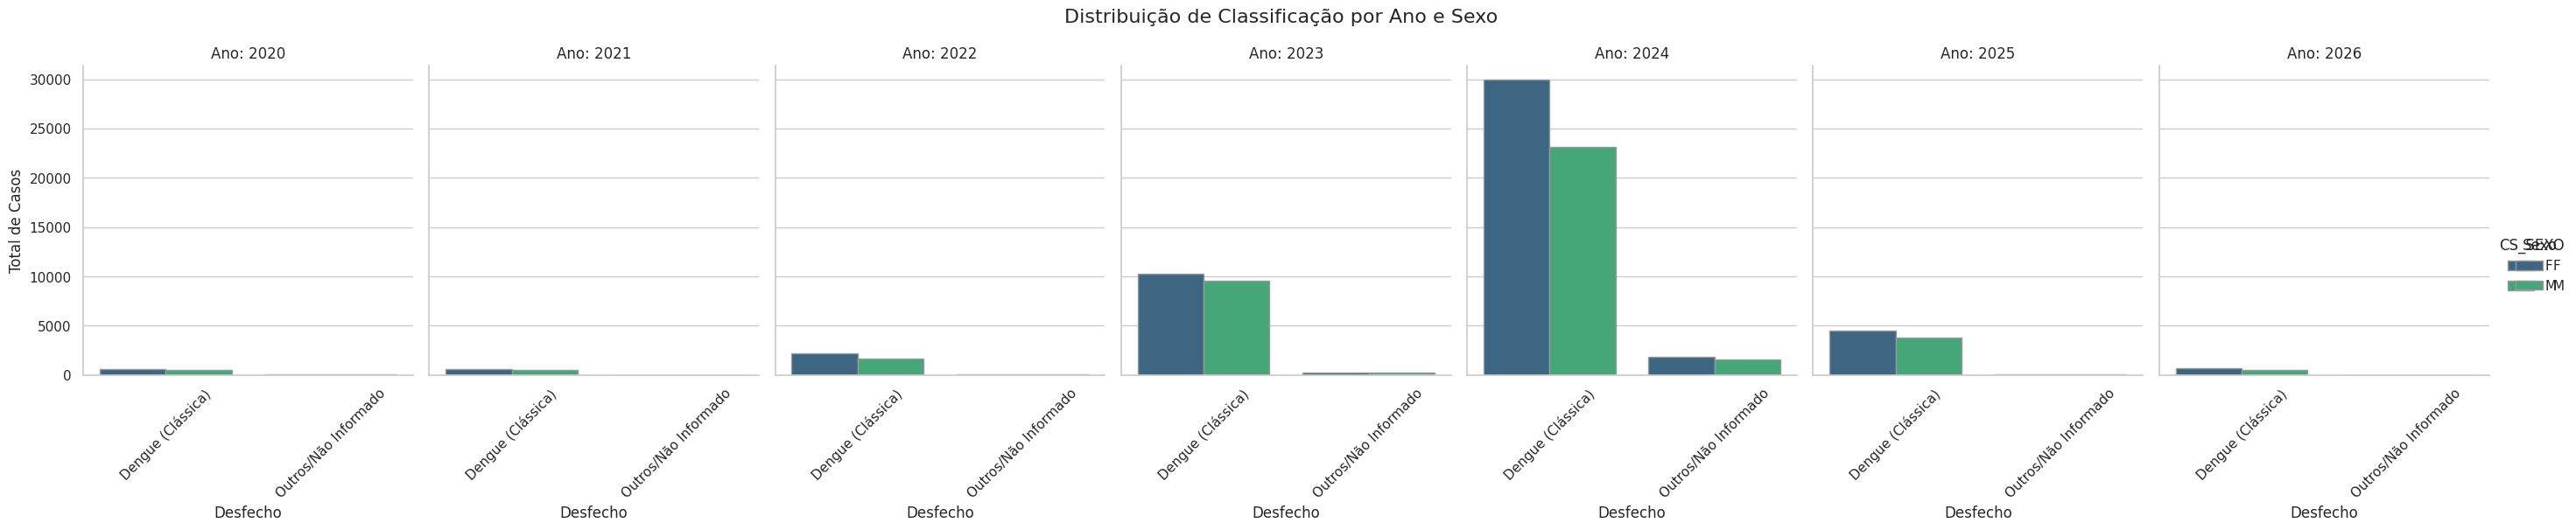

In [ ]:
df_grouped = df.groupby(['YEAR', 'CS_SEXO', 'DESFECHO']).size().reset_index(name='TOTAL')

# 2. Criando o gráfico facetado por Ano
g = sns.catplot(
    data=df_grouped,
    x='DESFECHO',
    y='TOTAL',
    hue='CS_SEXO',
    col='YEAR',
    kind='bar',
    palette='viridis',
    height=5,
    aspect=0.8,
    edgecolor='.6'
)

# 3. Ajustes de layout e títulos
g.set_axis_labels("Desfecho", "Total de Casos")
g.set_titles("Ano: {col_name}")
g.add_legend(title="Sexo")

# Rotacionar os nomes das categorias se forem longos (como "Confirmado Laboratorial")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Distribuição de Classificação por Ano e Sexo', fontsize=16)

plt.show()

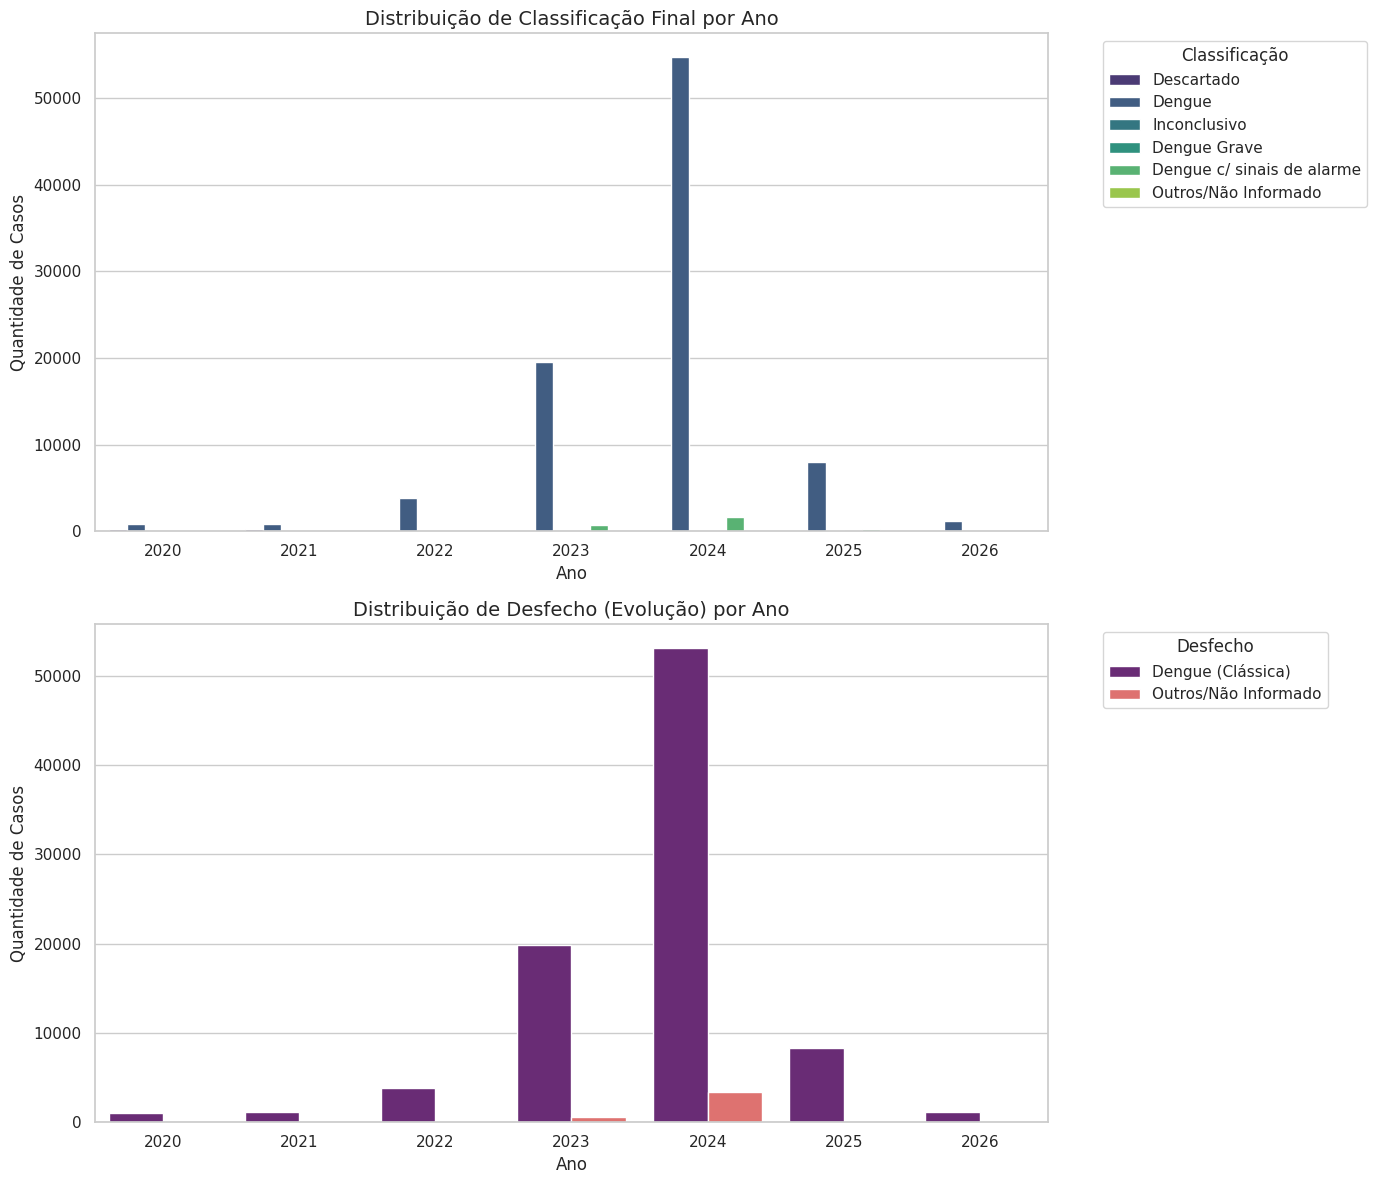

In [ ]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(2, 1, figsize=(14, 12))

# --- Classificação por Ano ---
sns.countplot(
    data=df,
    x='YEAR',
    hue='CLASSIFICACAO',
    palette='viridis',
    ax=ax[0]
)
ax[0].set_title('Distribuição de Classificação Final por Ano', fontsize=14)
ax[0].set_ylabel('Quantidade de Casos')
ax[0].set_xlabel('Ano')
ax[0].legend(title='Classificação', bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Desfecho (Evolução) por Ano ---
sns.countplot(
    data=df,
    x='YEAR',
    hue='DESFECHO',
    palette='magma',
    ax=ax[1]
)
ax[1].set_title('Distribuição de Desfecho (Evolução) por Ano', fontsize=14)
ax[1].set_ylabel('Quantidade de Casos')
ax[1].set_xlabel('Ano')
ax[1].legend(title='Desfecho', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

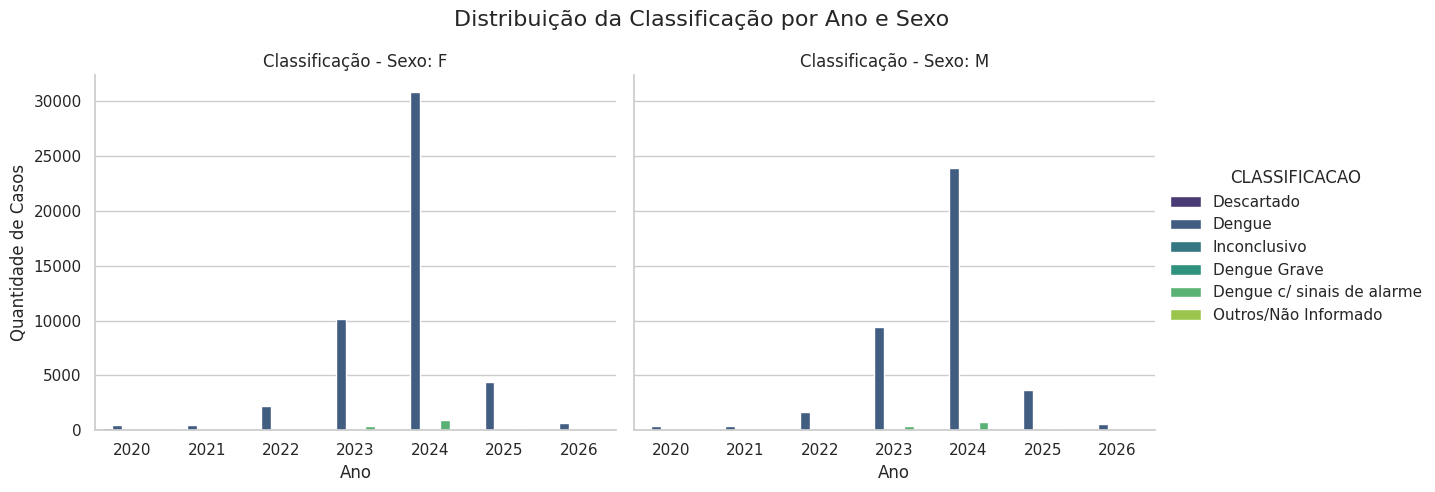

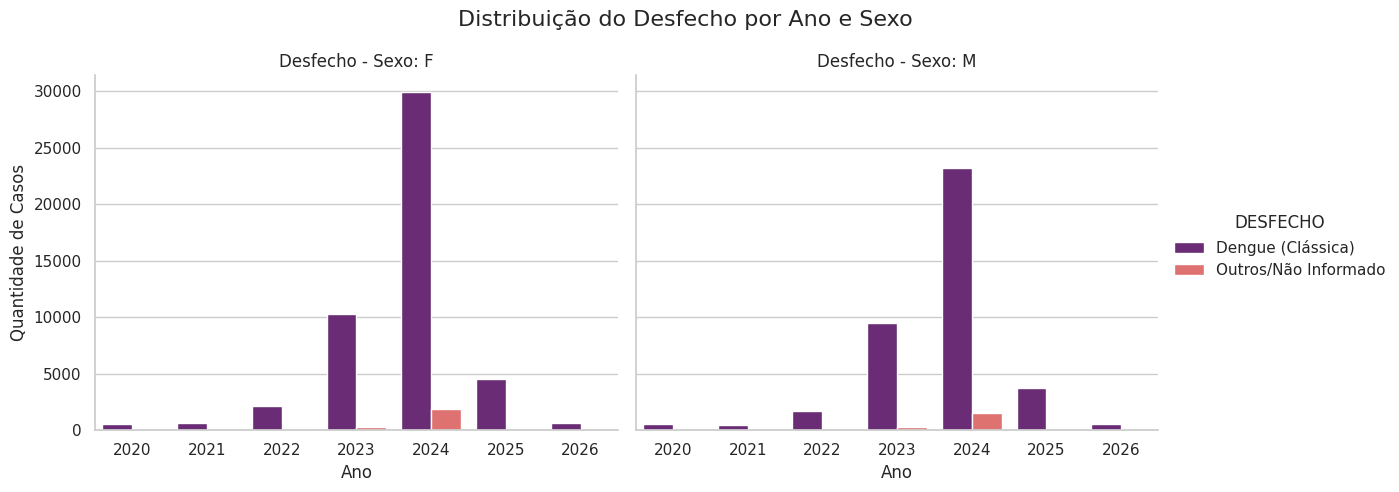

In [ ]:
sns.set_theme(style="whitegrid")

# --- Classificação por Ano e Sexo ---
g1 = sns.catplot(
    data=df,
    kind="count",
    x="YEAR",
    hue="CLASSIFICACAO",
    col="CS_SEXO",      # Separa homens e mulheres em colunas
    palette="viridis",
    height=5,
    aspect=1.2
)
g1.set_axis_labels("Ano", "Quantidade de Casos")
g1.set_titles("Classificação - Sexo: {col_name}")
g1.fig.subplots_adjust(top=0.85)
g1.fig.suptitle('Distribuição da Classificação por Ano e Sexo', fontsize=16)

# --- Desfecho por Ano e Sexo ---
g2 = sns.catplot(
    data=df,
    kind="count",
    x="YEAR",
    hue="DESFECHO",
    col="CS_SEXO",      # Separa homens e mulheres em colunas
    palette="magma",
    height=5,
    aspect=1.2
)
g2.set_axis_labels("Ano", "Quantidade de Casos")
g2.set_titles("Desfecho - Sexo: {col_name}")
g2.fig.subplots_adjust(top=0.85)
g2.fig.suptitle('Distribuição do Desfecho por Ano e Sexo', fontsize=16)

plt.show()

### Análise Temporal (Sazonalidade)

In [ ]:
# Análise Temporal (Sazonalidade)
# Dengue é cíclica. Entender quando os casos explodem.

In [ ]:
# Agrupando por Ano e Mês (Sazonalidade Geral)
df_mensal = df.groupby(['YEAR', 'MONTH']).size().reset_index(name='CASOS')

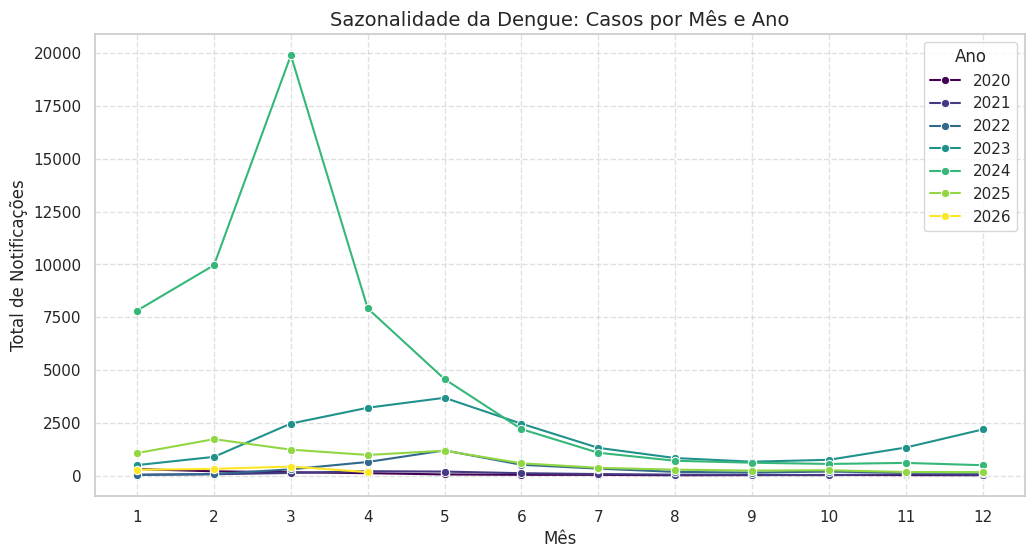

In [ ]:
# Sazonalidade da Dengue (Total por Ano)
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_mensal, x='MONTH', y='CASOS', hue='YEAR', marker='o', palette='viridis')

plt.title('Sazonalidade da Dengue: Casos por Mês e Ano', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Total de Notificações', fontsize=12)
plt.xticks(range(1, 13)) # Garante que todos os meses apareçam
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Ano')
plt.show()

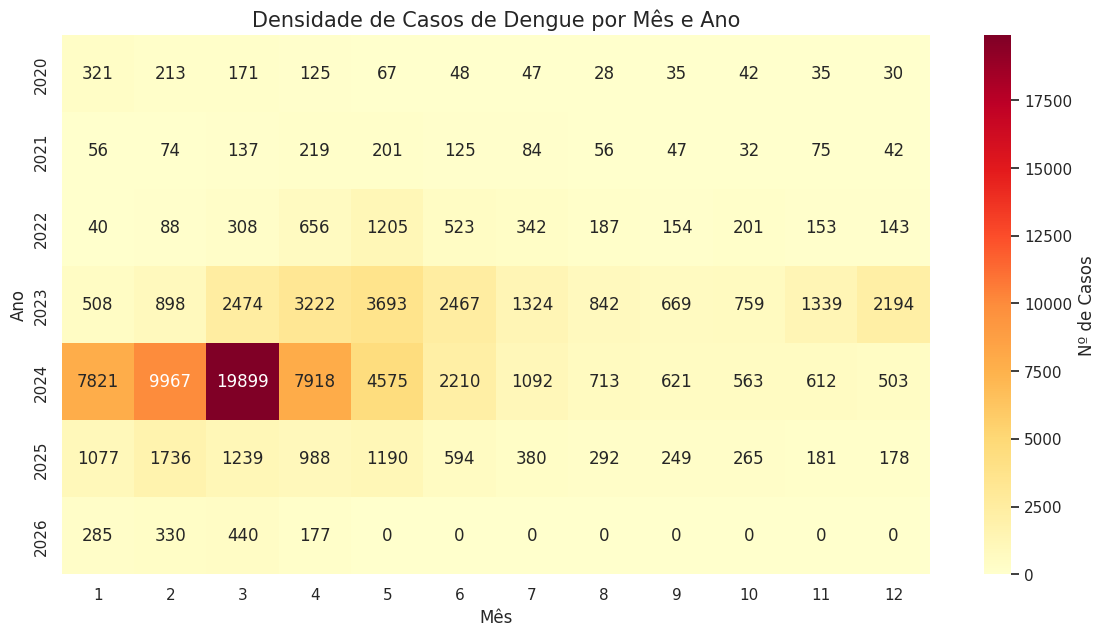

In [ ]:
pivot_df = df.groupby(['YEAR', 'MONTH']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_df, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Nº de Casos'})

plt.title('Densidade de Casos de Dengue por Mês e Ano', fontsize=15)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Ano', fontsize=12)
plt.show()

In [ ]:
# Agrupando os dados
df_area = df.groupby(['YEAR', 'MONTH', 'CS_SEXO']).size().unstack(fill_value=0)
# Criando um índice temporal para o eixo X
df_area.index = [f"{y}-{m:02d}" for y, m in df_area.index]

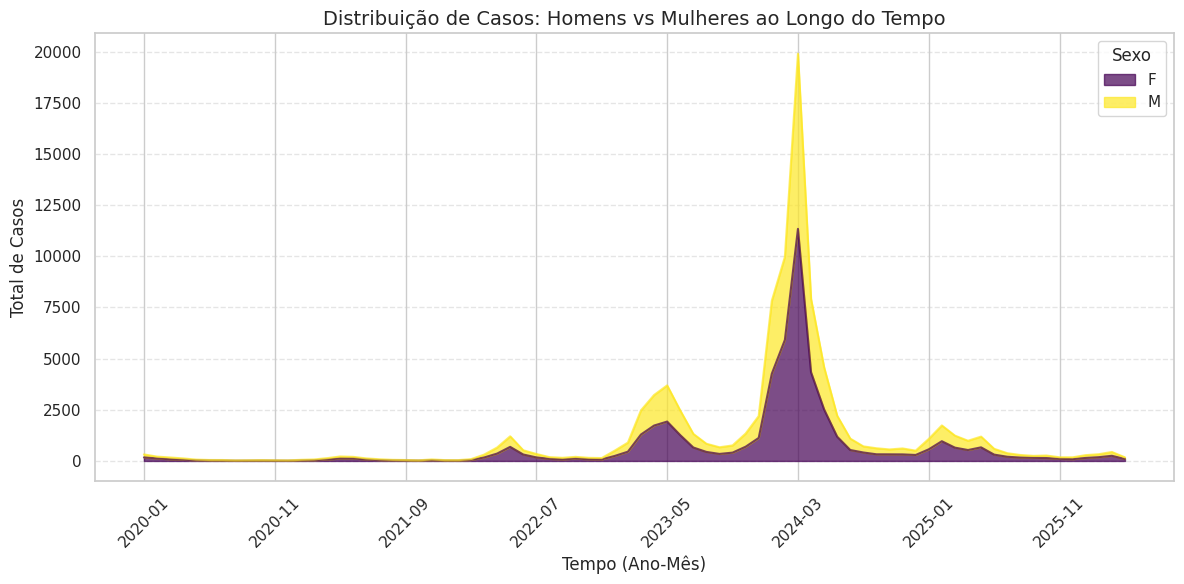

In [ ]:
df_area.plot(kind='area', stacked=True, figsize=(12, 6), alpha=0.7, colormap='viridis')

plt.title('Distribuição de Casos: Homens vs Mulheres ao Longo do Tempo', fontsize=14)
plt.xlabel('Tempo (Ano-Mês)', fontsize=12)
plt.ylabel('Total de Casos', fontsize=12)
plt.legend(title='Sexo')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

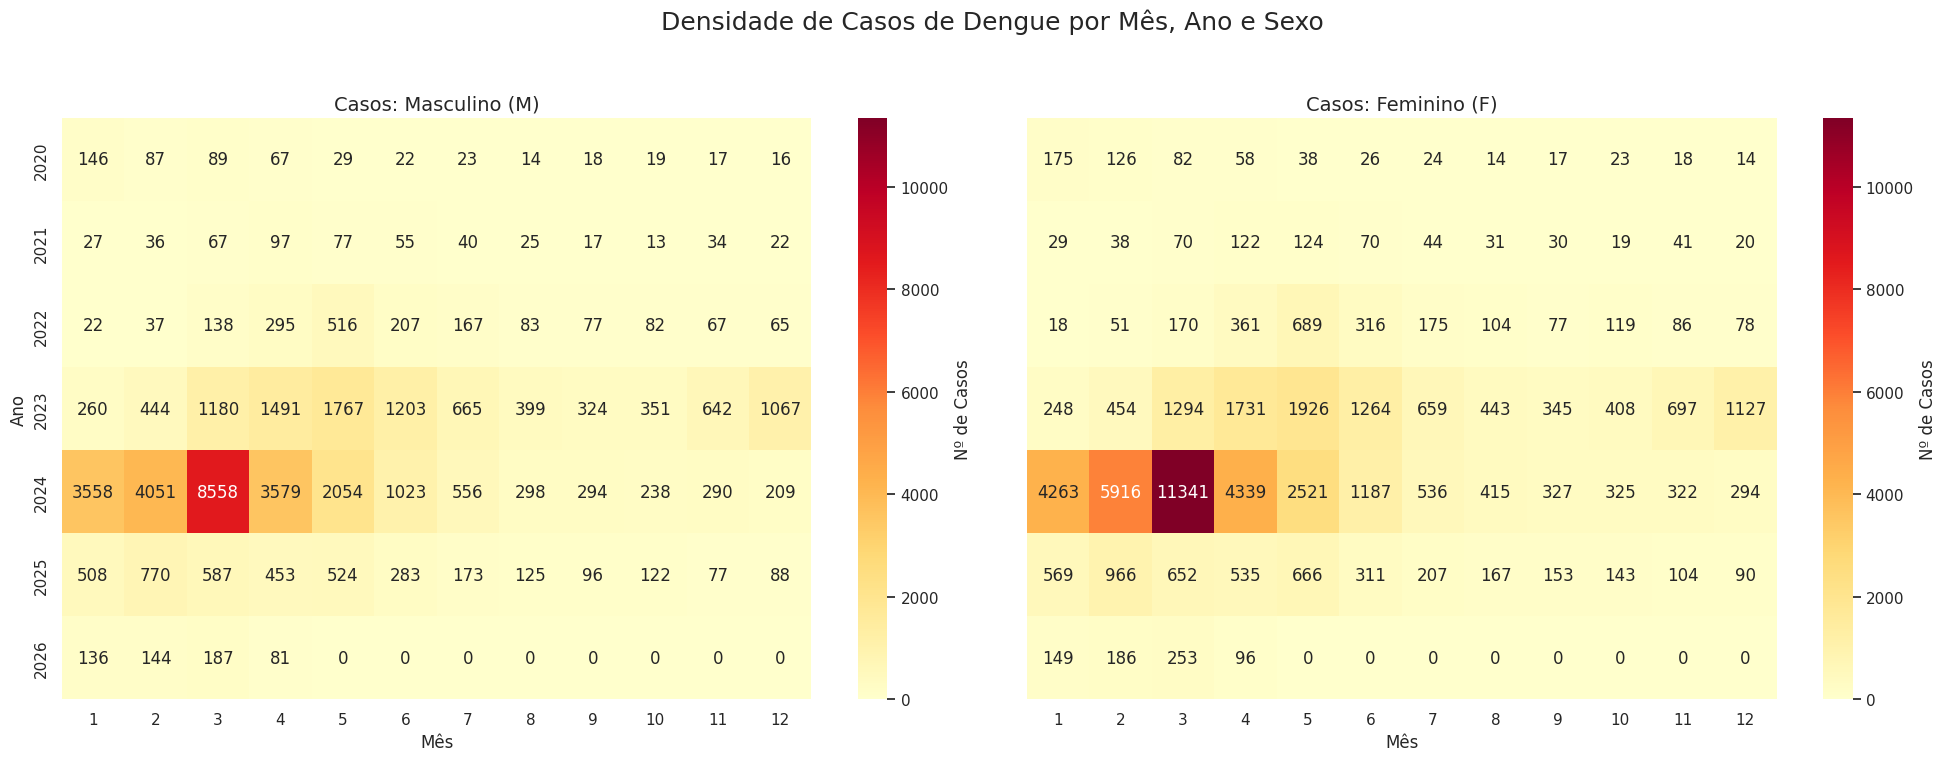

In [ ]:
df_clean = df[df['CS_SEXO'].isin(['M', 'F'])]

# Criando os pivots separadamente
# Para Masculino
pivot_m = df_clean[df_clean['CS_SEXO'] == 'M'].groupby(['YEAR', 'MONTH']).size().unstack(fill_value=0)
# Para Feminino
pivot_f = df_clean[df_clean['CS_SEXO'] == 'F'].groupby(['YEAR', 'MONTH']).size().unstack(fill_value=0)

# Configurando a figura com 2 subplots (1 linha, 2 colunas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Definindo um valor máximo comum para a escala de cores (vmax)
# Isso garante que a comparação de cores entre os dois gráficos seja justa
v_max = max(pivot_m.values.max(), pivot_f.values.max())

# Heatmap Masculino
sns.heatmap(pivot_m, annot=True, fmt="d", cmap="YlOrRd", ax=ax1, vmax=v_max, cbar_kws={'label': 'Nº de Casos'})
ax1.set_title('Casos: Masculino (M)', fontsize=14)
ax1.set_xlabel('Mês')
ax1.set_ylabel('Ano')

# Heatmap Feminino
sns.heatmap(pivot_f, annot=True, fmt="d", cmap="YlOrRd", ax=ax2, vmax=v_max, cbar_kws={'label': 'Nº de Casos'})
ax2.set_title('Casos: Feminino (F)', fontsize=14)
ax2.set_xlabel('Mês')
ax2.set_ylabel('') # Remove label do Y para não repetir

plt.suptitle('Densidade de Casos de Dengue por Mês, Ano e Sexo', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
df_sexo = df.groupby(['YEAR', 'MONTH', 'CS_SEXO']).size().reset_index(name='CASOS')

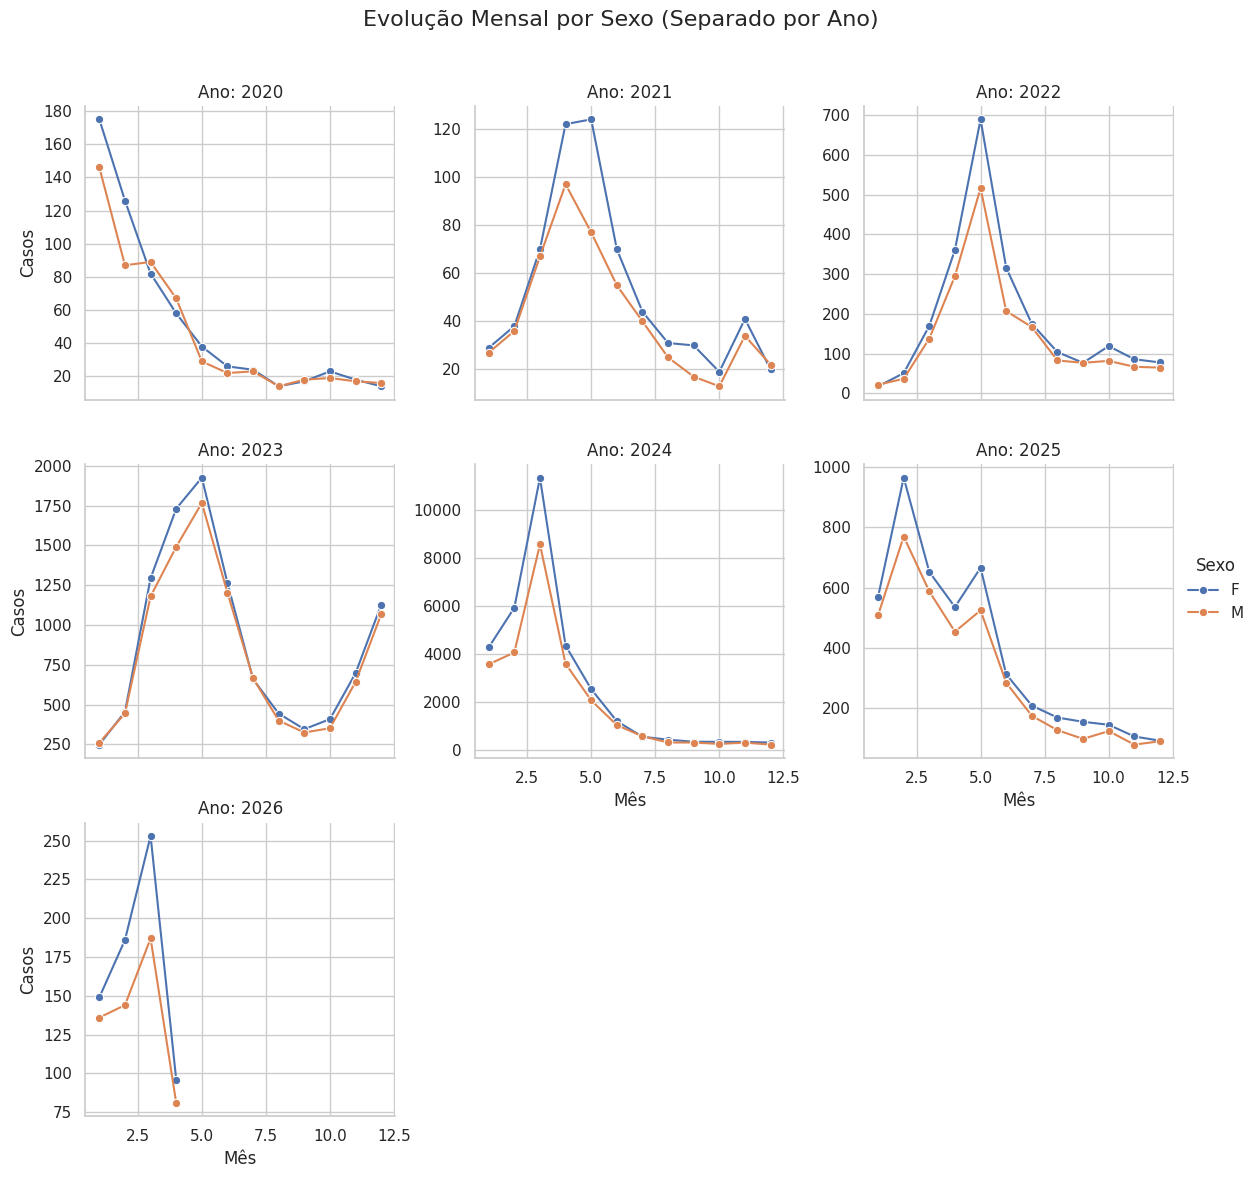

In [ ]:
g = sns.FacetGrid(df_sexo, col="YEAR", hue="CS_SEXO", col_wrap=3, height=4, sharey=False)
g.map(sns.lineplot, "MONTH", "CASOS", marker="o")

g.set_axis_labels("Mês", "Casos")
g.set_titles("Ano: {col_name}")
g.add_legend(title="Sexo")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Evolução Mensal por Sexo (Separado por Ano)', fontsize=16)
plt.show()

### Comorbidades e Fatores de Risco

##### Descrição doenças
1. DIABETES (Diabetes Mellitus)
Indica se o paciente já possui níveis elevados de açúcar no sangue.

Por que importa na Dengue: O diabetes pode comprometer a resposta imunológica e afetar a circulação sanguínea, tornando o corpo menos eficiente em combater o vírus e aumentando as chances de choque.

2. HIPERTENSA (Hipertensão Arterial)
Refere-se à famosa "pressão alta".

Por que importa na Dengue: Como a Dengue pode causar extravasamento de plasma (líquido saindo dos vasos), o sistema cardiovascular de um hipertenso já está sob estresse, o que pode complicar muito o manejo clínico da hidratação do paciente.

3. RENAL (Doença Renal Crônica)
Indica se o paciente tem problemas no funcionamento dos rins.

Por que importa na Dengue: O tratamento da Dengue baseia-se em hidratação intensa (muito soro). Se os rins não funcionam bem, o médico precisa ter um cuidado extremo para não sobrecarregar o corpo com líquido, criando um equilíbrio muito delicado.

4. HEMATOLOG (Doenças Hematológicas)
Refere-se a doenças do sangue (como anemia falciforme, talassemia ou histórico de leucemia).

Por que importa na Dengue: A Dengue ataca as plaquetas (que ajudam na coagulação). Se a pessoa já tem uma doença sanguínea, o risco de hemorragias graves e queda crítica de plaquetas é muito maior.

5. HEPATOPAT (Hepatopatias / Doenças do Fígado)
Indica doenças no fígado, como cirrose ou hepatites crônicas.

Por que importa na Dengue: O vírus da Dengue costuma causar uma inflamação no fígado (hepatite viral). Se o fígado do paciente já está doente, essa inflamação pode levar à insuficiência hepática aguda.

##### Dado

In [ ]:
# Comorbidades e Fatores de Risco
# O SINAN possui campos para doenças pré-existentes que podem agravar a dengue.

# Lista das suas colunas de comorbidade
comorbidades = ['DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG', 'HEPATOPAT']
df[comorbidades]

,DIABETES,HIPERTENSA,RENAL,HEMATOLOG,HEPATOPAT
DT_SIN_PRI,,,,,
2020-01-01,1.0,2.0,2.0,2.0,2.0
2020-01-01,2.0,2.0,2.0,2.0,2.0
2020-01-01,2.0,2.0,2.0,2.0,2.0
2020-01-01,2.0,1.0,2.0,2.0,2.0
2020-01-01,2.0,1.0,2.0,2.0,2.0
...,...,...,...,...,...
2026-04-22,2.0,2.0,2.0,2.0,2.0
2026-04-22,2.0,1.0,2.0,2.0,2.0
2026-04-22,2.0,2.0,2.0,2.0,2.0


In [ ]:
# Criando um DF focado nelas (considerando que 1 = Sim)
df_comorb = df.melt(id_vars=['YEAR', 'CS_SEXO'], value_vars=comorbidades,
                    var_name='Comorbidade', value_name='Presente')

In [ ]:
# Filtrando apenas onde a doença está presente (ajuste o '1' conforme seu encoding)
df_presente = df_comorb[df_comorb['Presente'] == 1]

/tmp/ipykernel_1329/1029684795.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_presente, x='Comorbidade', palette='magma', order=df_presente['Comorbidade'].value_counts().index)


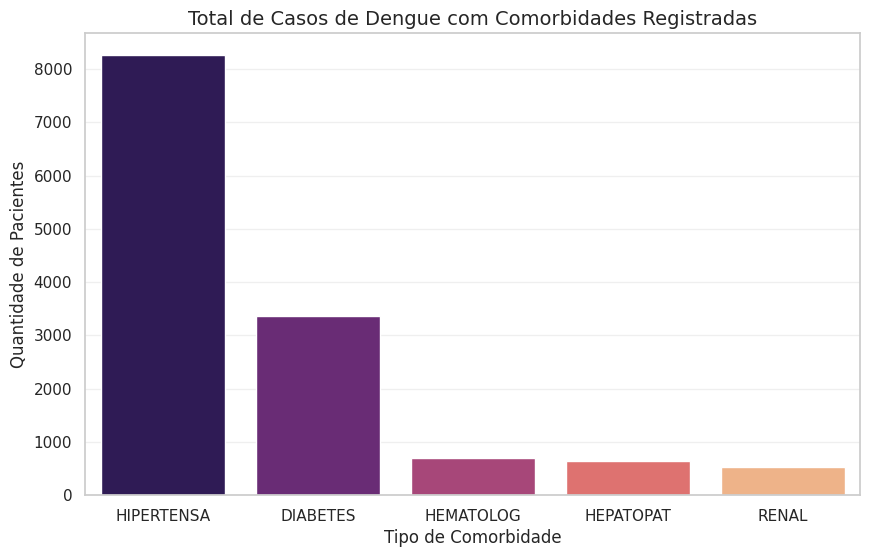

In [ ]:
# Total: Prevalência de Comorbidades
# Este gráfico mostra qual doença pré-existente aparece com mais frequência nos registros de Dengue
plt.figure(figsize=(10, 6))
sns.countplot(data=df_presente, x='Comorbidade', palette='magma', order=df_presente['Comorbidade'].value_counts().index)

plt.title('Total de Casos de Dengue com Comorbidades Registradas', fontsize=14)
plt.xlabel('Tipo de Comorbidade', fontsize=12)
plt.ylabel('Quantidade de Pacientes', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

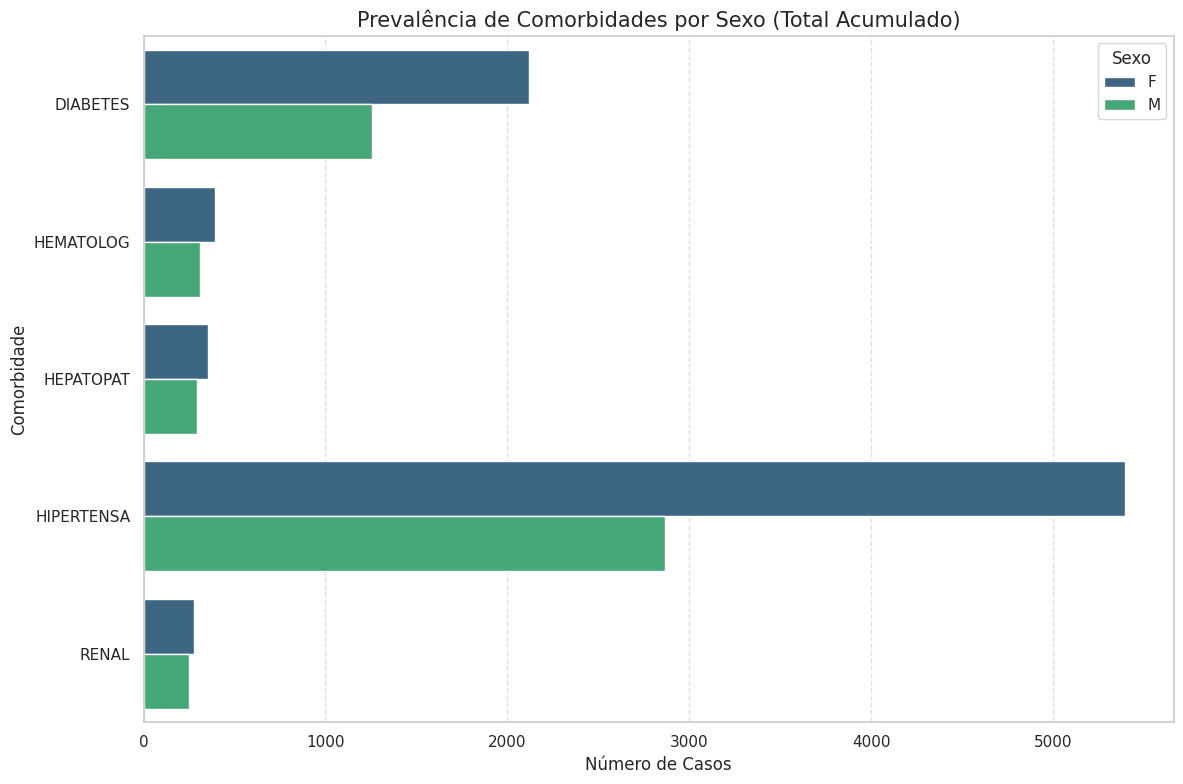

In [ ]:
plt.figure(figsize=(12, 8))

# Criando a contagem
df_sexo_comorb = df_presente.groupby(['Comorbidade', 'CS_SEXO']).size().reset_index(name='CONTAGEM')

# Plotando
sns.barplot(data=df_sexo_comorb, y='Comorbidade', x='CONTAGEM', hue='CS_SEXO', palette='viridis')

plt.title('Prevalência de Comorbidades por Sexo (Total Acumulado)', fontsize=15)
plt.xlabel('Número de Casos', fontsize=12)
plt.ylabel('Comorbidade', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

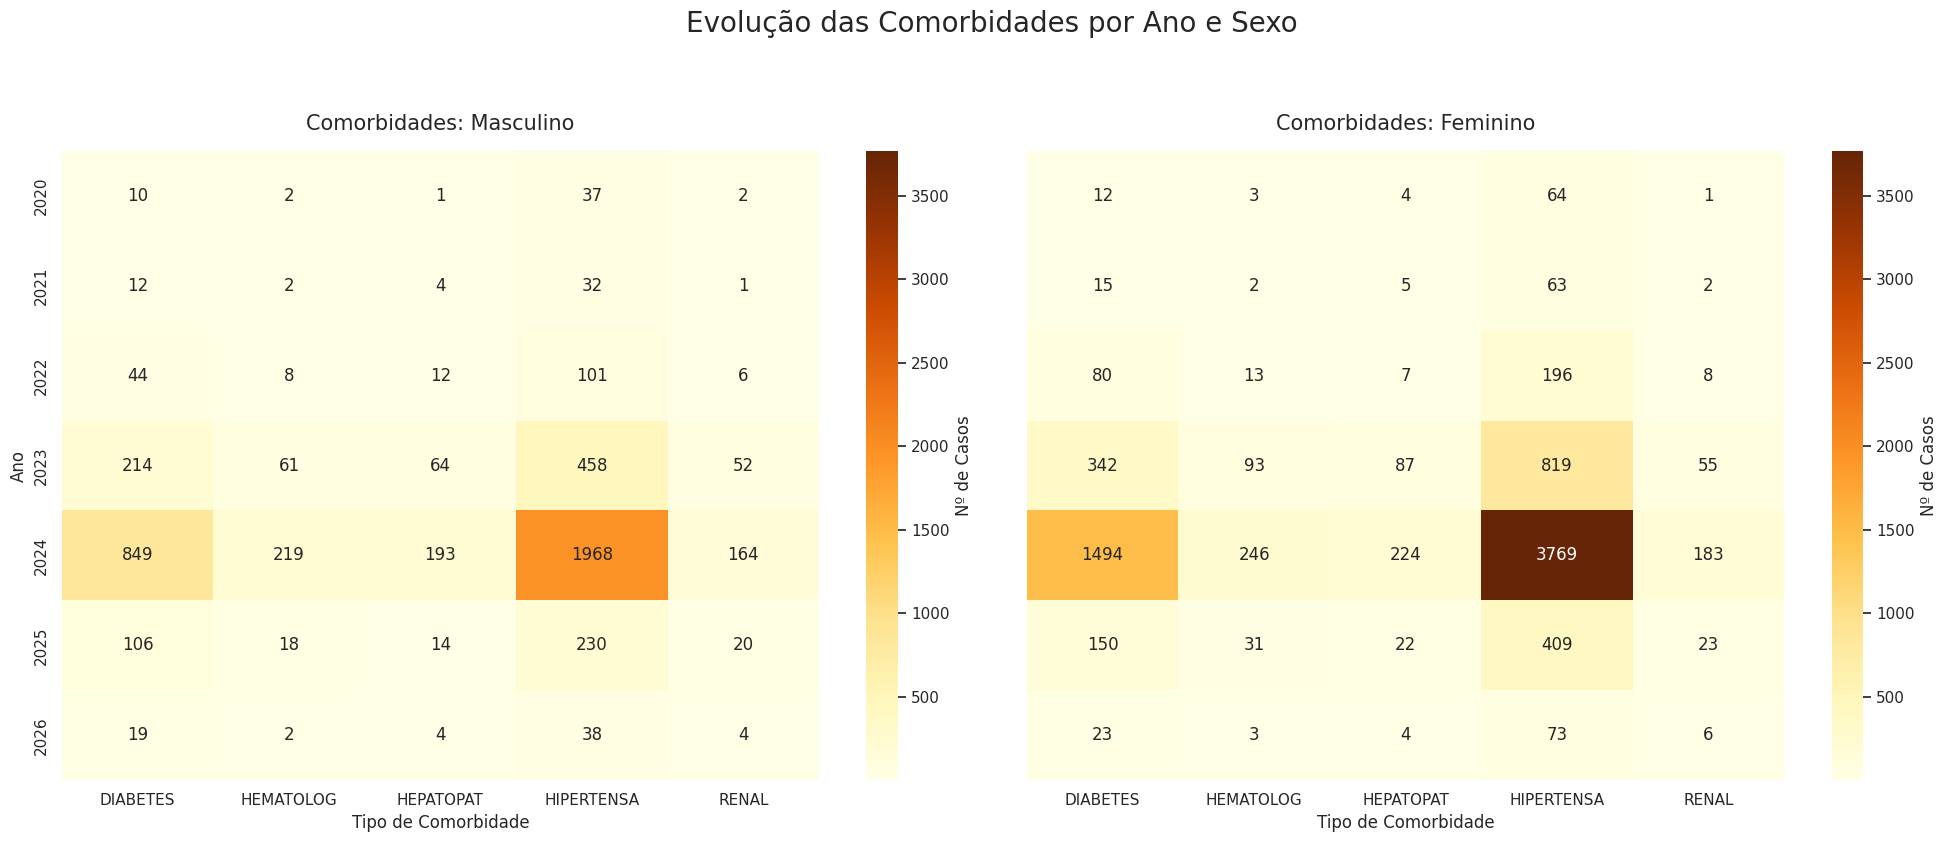

In [ ]:
# Heatmap de Proporção (Foco em Ano e Sexo)
# 1. Preparando os dados: Filtrando apenas casos onde a comorbidade existe (valor 1)
comorbidades = ['DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG', 'HEPATOPAT']
df_melt = df.melt(id_vars=['YEAR', 'CS_SEXO'], value_vars=comorbidades,
                  var_name='Comorbidade', value_name='Presente')
df_presente = df_melt[df_melt['Presente'] == 1]

# 2. Criando os pivots para cada sexo
# Eixo Y = Ano, Eixo X = Comorbidade
pivot_m = df_presente[df_presente['CS_SEXO'] == 'M'].groupby(['YEAR', 'Comorbidade']).size().unstack(fill_value=0)
pivot_f = df_presente[df_presente['CS_SEXO'] == 'F'].groupby(['YEAR', 'Comorbidade']).size().unstack(fill_value=0)

# 3. Configurando a visualização lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Definimos um valor máximo para que as cores sejam comparáveis entre os dois gráficos
v_max = max(pivot_m.values.max(), pivot_f.values.max())

# Heatmap Masculino
sns.heatmap(pivot_m, annot=True, fmt="d", cmap="YlOrBr", ax=ax1, vmax=v_max, cbar_kws={'label': 'Nº de Casos'})
ax1.set_title('Comorbidades: Masculino', fontsize=15, pad=15)
ax1.set_xlabel('Tipo de Comorbidade')
ax1.set_ylabel('Ano')

# Heatmap Feminino
sns.heatmap(pivot_f, annot=True, fmt="d", cmap="YlOrBr", ax=ax2, vmax=v_max, cbar_kws={'label': 'Nº de Casos'})
ax2.set_title('Comorbidades: Feminino', fontsize=15, pad=15)
ax2.set_xlabel('Tipo de Comorbidade')
ax2.set_ylabel('') # Oculta o Y pois é compartilhado com o gráfico da esquerda

plt.suptitle('Evolução das Comorbidades por Ano e Sexo', fontsize=20, y=1.05)
plt.tight_layout()
plt.show()

### Tempo de Diagnóstico (Delay) - TODO

In [ ]:
# Tempo de Diagnóstico (Delay)
# Interessante para avaliar a agilidade do sistema de saúde.

# Cálculo: Diferença entre DT_SIN_PRI (Data do início dos sintomas) e DT_NOTIFIC.

# Análise: Qual a média de dias que um paciente leva para buscar atendimento após os primeiros sintomas?

In [ ]:
# mas para um cálculo de precisão de "dias de atraso",
# o ideal é que você tenha as colunas originais de data (como DT_SIN_PRI e DT_NOTIFIC) no formato datetime.

# df['DELAY'] = (df['DT_NOTIFIC'] - df['DT_SIN_PRI']).dt.days
# df_plot = df[(df['DELAY'] >= 0) & (df['DELAY'] <= 30)]

In [ ]:
# Distribuição Geral do Delay (Histograma)
# plt.figure(figsize=(10, 6))
# # Filtrando delays negativos (erros de digitação) e valores muito extremos para não poluir o gráfico
# sns.histplot(df[df['DELAY'].between(0, 15)]['DELAY'], kde=True, color='teal', bins=15)

# plt.title('Distribuição do Tempo de Diagnóstico (Sintoma até Notificação)', fontsize=14)
# plt.xlabel('Dias de Atraso', fontsize=12)
# plt.ylabel('Frequência de Casos', fontsize=12)
# plt.grid(axis='y', alpha=0.3)
# plt.show()

In [ ]:
# plt.figure(figsize=(12, 7))

# # Criando o boxplot comparativo
# sns.boxplot(data=df[df['DELAY'].between(0, 15)], x='YEAR', y='DELAY', hue='CS_SEXO', palette='Set2')

# plt.title('Comparação do Atraso de Notificação por Ano e Sexo', fontsize=15)
# plt.xlabel('Ano', fontsize=12)
# plt.ylabel('Dias (Sintoma até Notificação)', fontsize=12)
# plt.legend(title='Sexo', loc='upper right')
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.show()

# Save

In [ ]:
df.shape, df.columns

((92794, 35),
 Index(['CS_SEXO', 'CS_GESTANT', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA',
        'VOMITO', 'NAUSEA', 'DOR_RETRO', 'ARTRALGIA', 'ARTRITE', 'CONJUNTVIT',
        'PETEQUIA_N', 'LACO', 'DIABETES', 'HIPERTENSA', 'RENAL', 'HEMATOLOG',
        'HEPATOPAT', 'CLASSI_FIN', 'EVOLUCAO', 'IDADE', 'FAIXA_ETARIA', 'YEAR',
        'MONTH', 'DAY_WEEK', 'DAY_MONTH', 'DAY_MONTH_START', 'DAY_MONTH_END',
        'DAY_QUARTER_START', 'DAY_QUARTER_END', 'DAY_YEAR_START',
        'DAY_YEAR_END', 'CLASSIFICACAO', 'DESFECHO'],
       dtype='object'))

In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df.head()

,CS_SEXO,CS_GESTANT,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_RETRO,ARTRALGIA,...,DAY_WEEK,DAY_MONTH,DAY_MONTH_START,DAY_MONTH_END,DAY_QUARTER_START,DAY_QUARTER_END,DAY_YEAR_START,DAY_YEAR_END,CLASSIFICACAO,DESFECHO
DT_SIN_PRI,,,,,,,,,,,,,,,,,,,,,
2020-01-01,F,5.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,...,2,1,1,0,1,0,1,0,Descartado,Dengue (Clássica)
2020-01-01,F,5.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,...,2,1,1,0,1,0,1,0,Descartado,Dengue (Clássica)
2020-01-01,M,6.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,...,2,1,1,0,1,0,1,0,Dengue,Dengue (Clássica)
2020-01-01,F,5.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,...,2,1,1,0,1,0,1,0,Dengue,Outros/Não Informado
2020-01-01,M,6.0,1.0,1.0,2.0,1.0,2.0,2.0,2.0,1.0,...,2,1,1,0,1,0,1,0,Dengue,Dengue (Clássica)


In [ ]:
df.index

DatetimeIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01', '2020-01-01', '2020-01-01',
               '2020-01-01', '2020-01-01',
               ...
               '2026-04-21', '2026-04-21', '2026-04-21', '2026-04-21',
               '2026-04-22', '2026-04-22', '2026-04-22', '2026-04-22',
               '2026-04-22', '2026-04-23'],
              dtype='datetime64[ns]', name='DT_SIN_PRI', length=92794, freq=None)

In [ ]:
path_dengue_rj = '/content/drive/MyDrive/ML-UFF/dengue_rj_2020_2026_analise.csv'
save_data_frame(df, path_dengue_rj)

# Cenário da dengue na cidade do Rio de Janeiro

O cenário da dengue no Rio de Janeiro entre 2020 e 2024 revela um contraste impressionante, transformando o que parecia um período de "calmaria" em uma das maiores crises de saúde pública da década.

Resumo do que os dados do SINAN (Sistema de Informação de Agravos de Notificação) e os boletins epidemiológicos indicam sobre esse período:

A Linha do Tempo: Do Silêncio à Explosão
- 2020 - 2022: O "Efeito Pandemia"
Durante o auge da COVID-19, os registros de dengue foram historicamente baixos. Especialistas debatem se houve uma queda real na transmissão ou se o isolamento social e a sobrecarga do sistema de saúde causaram uma subnotificação massiva.

- 2023: O Sinal de Alerta
Os números começaram a subir gradualmente, servindo como um prenúncio do que viria a seguir.

- 2024: O Grande Pico (Ano Epidêmico)
O Rio de Janeiro viveu uma explosão de casos. Em fevereiro de 2024, a prefeitura chegou a decretar estado de emergência.

- Fatores do Pico: A combinação do calor extremo (El Niño), o retorno do sorotipo DENV-3 (ao qual a população tinha pouca imunidade) e o acúmulo de criadouros em áreas urbanas.

- 2025 - 2026: Projeções e Realidade
Após um pico como o de 2024, a tendência natural é uma leve queda pela imunidade de grupo temporária, mas o monitoramento segue rigoroso devido às mudanças climáticas que favorecem o Aedes aegypti.


Por que 2024 foi tão atípico?

Sorotipos em Circulação: A reintrodução de linhagens que não circulavam há anos encontrou uma população suscetível.

Fator Climático: As ondas de calor recordes aceleram o ciclo de reprodução do mosquito.

Urbanização: A densidade populacional do Rio facilita a propagação rápida em curtíssimo espaço de tempo.

Nota importante: Como estamos em maio de 2026, os dados consolidados de 2025 e o início de 2026 mostram se as campanhas de vacinação (iniciadas em larga escala no ano passado) surtiram o efeito esperado de achatar a curva após o desastre de 2024.

In [ ]:
# Ano	Situação Epidemiológica	Intensidade
# 2020	Baixa incidência	Controlada
# 2021	Baixa incidência	Controlada
# 2022	Leve aumento	Atenção
# 2023	Transmissão moderada	Alerta
# 2024	Pico Epidêmico	Emergência
# 2025	Endemia persistente	Vigilância

Justificativas detalhadas e os dados consolidados, o documento mais robusto é o Plano Municipal de Contingência de Arboviroses (2024-2026), publicado pela Secretaria Municipal de Saúde do Rio de Janeiro.

Este plano não só apresenta os números, mas analisa os motivos técnicos que levaram ao pico de 2024. Abaixo, separei os links diretos e os pontos principais citados nesses relatórios:

1. Plano Municipal de Contingência (SMS-RJ)
Este é o guia técnico oficial da Prefeitura do Rio. Ele detalha a estratégia de enfrentamento e a análise epidemiológica que justifica as ações entre 2024 e 2026.

- Link: Plano Municipal de Contingência de Arboviroses - Rio de Janeiro - https://epirio.svs.rio.br/publicacoes/plano-municipal-de-contingencia-de-arboviroses-dengue-chikungunya-e-zika-2024-2026/


2. Decreto de Estado de Emergência (Fev/2024)
O Decreto Rio nº 53.921 é o documento jurídico-administrativo que oficializou o pico. No texto, o prefeito justifica a medida com base no "aumento do número de casos sustentados" e nas "análises do Centro de Informações Epidemiológicas (CIE)".

- Link: Decreto Rio Nº 53.921 - Estado de Emergência - https://doweb.rio.rj.gov.br/apifront/portal/edicoes/imprimir_materia/1028295/6287


Por que os relatórios justificam esse pico em 2024?

De acordo com os boletins da Fiocruz (InfoDengue) e da Secretaria de Saúde, os relatórios oficiais apontam três culpados principais:


1. Mudanças Climáticas e El Niño:
O relatório destaca que o calor extremo e o regime de chuvas atípico em 2023/2024 aceleraram o ciclo de vida do Aedes aegypti.

2. Cocirculação de Sorotipos:
Em 2024, o Rio enfrentou a circulação simultânea de DENV-1, DENV-2 e a reintrodução do DENV-3. Quando um novo tipo de vírus volta a circular após anos (o tipo 3 não era predominante desde 2007), ele encontra uma população sem anticorpos, causando o pico.

3. Acúmulo de Suscetíveis:
O período de 2020 a 2022 teve poucos casos (muito por conta do isolamento da pandemia), o que gerou uma "massa" de pessoas que nunca haviam tido dengue e ficaram expostas de uma só vez em 2024.

Resumo dos Dados Citados nos Relatórios:
- 2023: Aproximadamente 51 mil casos em todo o estado.

- 2024: Salto para mais de 300 mil casos prováveis no estado (com a capital registrando a maior epidemia da década, ultrapassando 111 mil casos apenas na cidade).

- 2025/2026: Os relatórios atuais (de maio de 2026) já avaliam o impacto da vacina aplicada no público de 10 a 14 anos como ferramenta de controle para evitar a repetição do desastre de 2024.